# Clustering Knowledge Articles for AI-Readiness Assessment (Technical Slides)

**Capstone Project – AI & Machine Learning**  
Author: Aicel Mae Alvarez
Program: Post Graduate Diploma in AI and Machine Learning  

Dataset: Stack Exchange Posts (public dataset)  
Approach: Unsupervised Learning (Clustering)


## Problem Framing

Enterprise AI assistants (e.g., Moveworks) require knowledge articles that are structurally clear, instructional, and AI-ready.

However, large knowledge bases often contain:
- Highly inconsistent article structures
- Mixed-quality content
- No ground-truth labels for AI readiness

**Objective:**  
Identify structural archetypes of knowledge articles using unsupervised learning to support AI-readiness assessment and prioritization.

**Data Science Task:**  
Unsupervised clustering of knowledge articles based on engineered structural features.


## Dataset Overview

**Source:** Stack Exchange public data dump  
**Rationale:**  
Stack Exchange Q&A posts closely resemble enterprise knowledge articles:
- How-to guides
- FAQs
- Troubleshooting instructions
- Code-heavy reference answers

**Working Sample:**
- ~10,000 question + accepted answer pairs
- XML parsed and converted to structured tabular format
- Sampling performed to fit Colab constraints

**Key Limitation:**  
Dataset represents community-driven content, not enterprise-authored KBs.


## Feature Engineering

Clustering focused on **structural and instructional signals**, not topic semantics.

Engineered features include:
- Answer length and question length
- Number of links
- Number of bullet points / list items
- Number of code blocks
- Title length
- Presence of tags

**Rationale:**  
Moveworks-style AI readiness depends on structure, clarity, and instructional quality rather than popularity or topic.


## Data Preprocessing & Dimensionality Reduction

Preprocessing steps:
- Null handling and duplicate removal
- Feature scaling (StandardScaler)
- Low-variance feature removal
- PCA for dimensionality reduction

**PCA Outcomes:**
- Reduced multicollinearity
- Noise reduction
- Improved cluster stability
- Majority of variance retained in reduced dimensions

PCA-reduced structured features were selected as the primary clustering space.
PCA analysis shows that the first two components capture approximately 85% of the total variance, and the full retained components explain over 95%, confirming that the engineered structural features are highly correlated and suitable for dimensionality reduction without significant information loss.


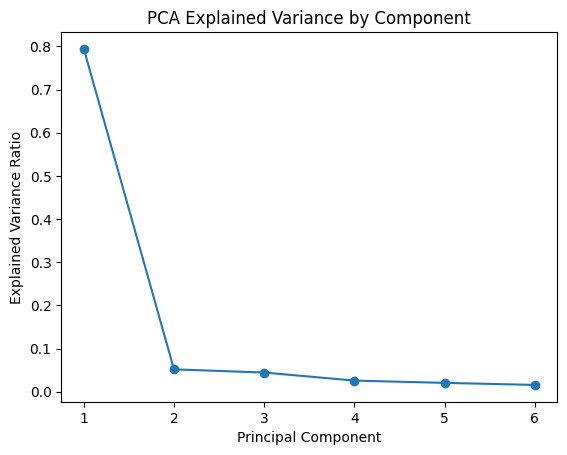

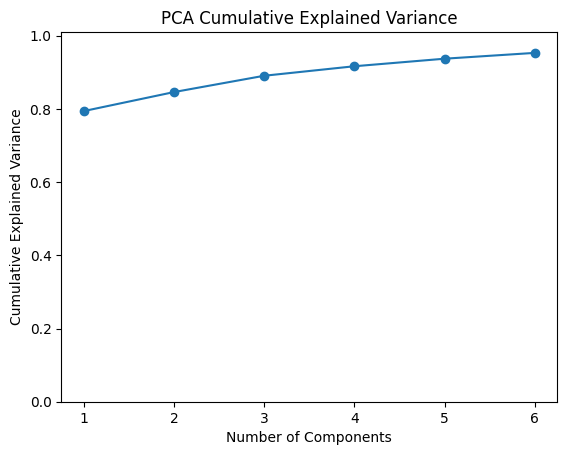

Number of PCA components: 6
Cumulative explained variance (first 2): 0.8462
Cumulative explained variance (first 5): 0.9374
Cumulative explained variance (all): 0.9533


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- PCA Explained Variance Diagnostic (read-only) ---
# If PCA isn't in memory (e.g., after restart), load it from saved artifacts.
try:
    pca
except NameError:
    import joblib, os
    MODELS_DIR = "/content/models"  # adjust if your artifacts are in Drive
    pca = joblib.load(os.path.join(MODELS_DIR, "pca.joblib"))

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Plot 1: per-component explained variance
plt.figure()
plt.plot(range(1, len(evr) + 1), evr, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance by Component")
plt.show()

# Plot 2: cumulative explained variance
plt.figure()
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.ylim(0, 1.01)
plt.show()

# Print summary to reference in slides/report
print("Number of PCA components:", len(evr))
print("Cumulative explained variance (first 2):", round(float(cum_evr[min(1, len(cum_evr)-1)]), 4))
print("Cumulative explained variance (first 5):", round(float(cum_evr[min(4, len(cum_evr)-1)]), 4))
print("Cumulative explained variance (all):", round(float(cum_evr[-1]), 4))


## Clustering Models Evaluated

Multiple unsupervised models were evaluated to ensure robustness:

- **K-Means**
  - Centroid-based clustering
  - Interpretable and scalable

- **Agglomerative Clustering**
  - Hierarchical baseline
  - Explores non-spherical clusters

- **DBSCAN**
  - Density-based clustering
  - Detects noise and outliers

All models were evaluated using internal validation metrics.


## Model Selection & Metrics

Primary evaluation metric:
- **Silhouette Score** (higher is better)

Secondary metrics:
- Davies–Bouldin Index (lower is better)
- Calinski–Harabasz Score (higher is better)

**Key Result (K-Means):**
- k = 3 → Silhouette ≈ 0.71
- Higher k values led to rapid performance degradation

**Decision:**  
k = 2 was excluded despite high silhouette due to trivial binary segmentation.  
k = 3 provided the best balance of performance and interpretability.


## Explainability of Cluster Decisions

K-Means does not provide intrinsic feature importance.

Approach used:
- Train a Random Forest surrogate model to predict cluster labels
- Apply SHAP to explain surrogate predictions

**Key Drivers of Cluster Separation:**
- Answer length
- Number of links
- Bullet/step structure
- Code block density

SHAP confirms clusters are driven by meaningful structural signals, not noise.


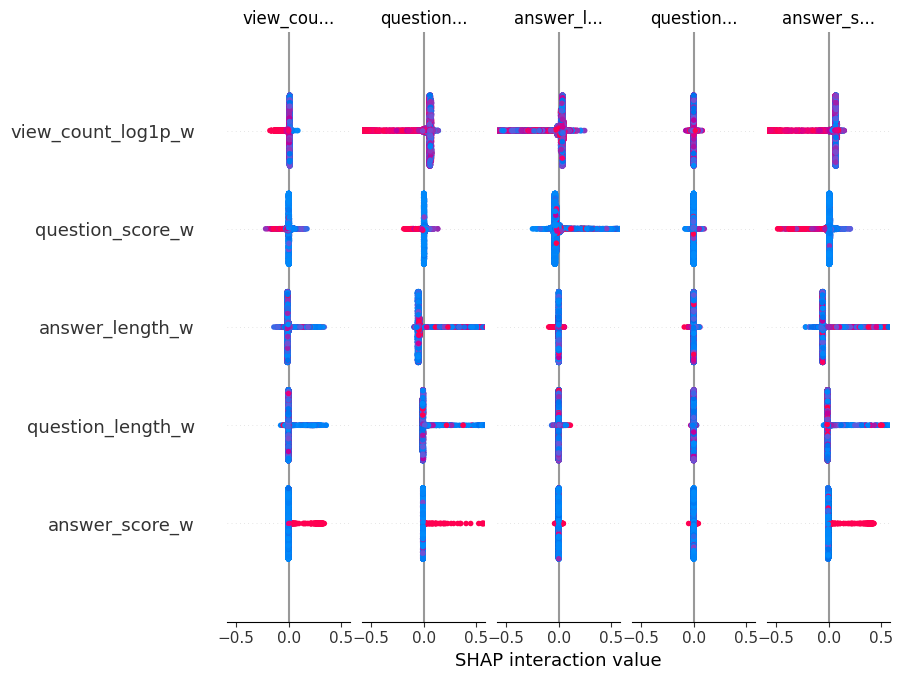

In [ ]:
shap.summary_plot(
    shap_values,
    X_struct,
    feature_names=structured_features,
    show=True
)


## Final Cluster Assignment

Using K-Means (k = 3), articles were assigned to clusters:

- **Cluster 0:** 9,315 articles
- **Cluster 1:** 504 articles
- **Cluster 2:** 181 articles

**Observation:**  
Cluster imbalance is expected in real-world knowledge bases and reflects the rarity of highly structured, AI-ready content.

Cluster labels are nominal and do not imply ordinal ranking.


## Ethical AI & Bias Analysis

No demographic attributes were available in the dataset.

Bias audits were performed using proxy-sensitive groups:
- Content age (cohort)
- Engagement level (view count quartiles)
- Code-heaviness
- Topic proxies (primary tags)

**Findings:**
- No temporal bias detected
- Structural bias observed across engagement and code-heavy content
- Risk lies in misuse of clusters as absolute quality labels


## Limitations

- No ground-truth labels for AI readiness
- Fairness analysis relies on proxy attributes
- Stack Exchange content differs from enterprise-authored knowledge
- Clustering captures structure, not semantic correctness

These limitations are explicitly documented and mitigated through careful interpretation.


## Conclusion

This project demonstrates an end-to-end unsupervised ML pipeline for:
- Structurally clustering knowledge articles
- Explaining cluster behavior using SHAP
- Auditing ethical risks and bias

The approach is robust, interpretable, and directly applicable to AI-readiness assessment in enterprise knowledge management systems.




---



# An AI-Readiness Evaluation Framework for Knowledge Articles Using Unsupervised Learning Aligned with Retrieval-Augmented Generation requirements for enterprise AI assistants such as Moveworks

# Step 1: Problem Understanding & Framing


## Problem Statement

This project aims to design and evaluate an unsupervised machine learning system that clusters enterprise-style knowledge articles based on semantic and structural features aligned with Moveworks AI-ready requirements. By identifying latent quality patterns without relying on labeled data, the system enables scalable assessment of AI-readiness, supports targeted knowledge improvements, and provides actionable insights to improve chatbot performance and self-service outcomes.

## Business Context

Modern enterprises rely heavily on large-scale knowledge bases to support employee self-service and AI-powered virtual agents such as **Moveworks**. As these knowledge bases grow organically across teams, regions, and time, they commonly suffer from structural and content quality issues that reduce their effectiveness when consumed by Retrieval-Augmented Generation (RAG) systems.

Moveworks explicitly requires knowledge articles to follow AI-ready writing and structural standards to ensure accurate intent detection, reliable retrieval, and high-quality responses from the bot.

**Exact source of Moveworks requirements:**
https://help.moveworks.com/docs/writing-ai-ready-kb-articles-for-the-moveworks-bot

However, in real-world enterprise environments:
* Knowledge articles are authored by many contributors with inconsistent standards.

* Manual reviews for AI-readiness do not scale.

* Poorly structured articles lead to low bot resolution rates, higher human case volumes, and reduced trust in AI assistants.

This creates a clear business need for an automated, scalable system that can:

1. Evaluate whether knowledge articles align with Moveworks AI-ready requirements.

2. Identify patterns of structural and semantic quality issues.

3. Support targeted improvements to make articles AI-ready.

## Data Science Problem Definition

From a data science perspective, this problem is framed as an **unsupervised learning task** applied to textual knowledge content.

The project does **not** rely on pre-existing labels such as “AI-ready” or “not AI-ready.” Instead, it infers quality patterns from the data itself using measurable proxies derived from Moveworks guidance, such as structure, clarity, redundancy, and semantic cohesion.

The goal is to group articles into **latent quality clusters** that represent different levels and types of AI-readiness, and then interpret these clusters in a business-relevant way.

## Task Type and Justification

| Aspect                 | Description                                                                                                                |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| Primary Task Type      | **Clustering (Unsupervised Learning)**                                                                                     |
| Why Not Classification | No ground-truth labels for “AI-ready” articles exist in public datasets; labeling would introduce subjectivity and leakage |
| Why Clustering Fits    | Enables discovery of natural groupings based on semantic and structural similarity                                         |
| Secondary Analysis     | Outlier detection (via DBSCAN) to identify duplicate or low-quality articles                                               |
| Optional Extension     | Post-hoc scoring and Generative AI rewriting, built on top of clustering outputs                                           |


**Clustering models** allow the project to remain faithful to real-world KM constraints while still demonstrating rigorous ML design and evaluation.

## Business Objective vs Data Science Objective

| Dimension         | Business Objective                  | Data Science Objective                            |
| ----------------- | ----------------------------------- | ------------------------------------------------- |
| Knowledge Quality | Improve AI-readiness of KB articles | Identify latent quality patterns in text          |
| Scalability       | Reduce manual article reviews       | Automate evaluation using embeddings and features |
| AI Performance    | Improve bot resolution and accuracy | Improve semantic cohesion and retrievability      |
| Governance        | Standardize article structure       | Cluster and interpret article archetypes          |


## Success Metrics (Technical)

Because this is an unsupervised task, success is evaluated using internal clustering quality metrics and interpretability.
| Metric               | Why It Is Used                           | Interpretation                                         |
| -------------------- | ---------------------------------------- | ------------------------------------------------------ |
| Silhouette Score     | Measures cluster cohesion and separation | Higher score indicates well-separated quality clusters |
| Davies–Bouldin Index | Measures cluster compactness             | Lower score indicates better clustering                |
| Inertia (K-Means)    | Used for elbow method                    | Helps identify optimal number of clusters              |
| Cluster Stability    | Validates robustness across runs         | Ensures results are not random                         |


These metrics collectively demonstrate whether the model has discovered meaningful structure in the data.

## Business KPIs and Impact Metrics

The clustering output is mapped to business-relevant KPIs, aligned with how Moveworks and enterprise KM teams measure success.

| Business KPI                | Description                                     | Expected Impact           |
| --------------------------- | ----------------------------------------------- | ------------------------- |
| % AI-Ready Articles         | Proportion of articles in high-quality clusters | Increases over time       |
| Duplicate Content Rate      | Articles flagged as near-duplicates             | Reduction                 |
| Manual Review Effort        | Time spent auditing articles                    | Cost and effort reduction |
| Bot Deflection Rate (Proxy) | Improved self-service resolution                | Higher deflection         |
| Knowledge Debt Visibility   | Number of low-quality clusters                  | Actionable prioritization |


These KPIs allow the technical output to be translated into executive-level value.

# Step 2: Data Collection & Understanding

## Dataset Source

This project uses the **Stack Exchange Data Dump**, hosted by Internet Archive.

**Official dataset URL:**
https://archive.org/details/stackexchange

**Specific file used in this project:**
stackoverflow.com-Posts.7z

This repository contains monthly XML data dumps for all Stack Exchange sites (including Stack Overflow, Superuser, etc.), published under a permissive license for research and analysis.

| Item             | Description                                       |
| ---------------- | ------------------------------------------------- |
| Original dataset | Stack Exchange Data Dump                          |
| Hosting platform | Internet Archive                                  |
| Data format      | XML                                               |
| Sampling method  | Tag-stratified sampling                           |
| Final dataset    | Representative subset of knowledge-style articles |
| Intended use     | AI-readiness evaluation and clustering            |


## Justification for Knowledge Management Use Case

| Enterprise KM Requirement  | Stack Exchange Data Characteristic                        |
| -------------------------- | --------------------------------------------------------- |
| How-to guides              | Procedural accepted answers                               |
| FAQs                       | Repeated questions with canonical answers                 |
| Quick reference guides     | Short, direct accepted answers                            |
| Policy-like content        | Rule-based, standards-oriented answers                    |
| Knowledge quality variance | Large differences in structure, clarity, and completeness |
| AI-readiness gaps          | Inconsistent titles, poor chunking, conversational tone   |


In this project, a knowledge article is defined as:

A Stack Overflow question paired with its accepted answer, representing finalized, authoritative knowledge similar to enterprise KB articles.

## Knowledge Article Mapping Used in This Project

| Enterprise Concept | Dataset Mapping             |
| ------------------ | --------------------------- |
| Knowledge article  | Question + accepted answer  |
| Article title      | Question title              |
| Article body       | Accepted answer body        |
| Taxonomy           | Tags                        |
| Article lifecycle  | Creation and activity dates |


## Use of a Sampled Subset

The full Stack Overflow Posts dataset exceeds several gigabytes and contains millions of records, which presents practical limitations for interactive experimentation and reproducible execution in cloud-based notebook environments such as Google Colab.

To address this, the project deliberately uses a controlled, stratified sample of the dataset rather than the full corpus.
| Consideration            | Rationale                                                                                             |
| ------------------------ | ----------------------------------------------------------------------------------------------------- |
| Computational efficiency | Enables repeatable execution within Colab memory and time limits                                      |
| Reproducibility          | Ensures consistent results across runs using a fixed random seed                                      |
| Methodological validity  | Unsupervised clustering does not require full population coverage to reveal latent structure          |
| Real-world alignment     | Mirrors enterprise KM practice, where audits and quality checks are applied to representative subsets |

## Sampling Strategy

A tag-stratified sampling approach is used to preserve topical diversity across the knowledge base.

| Aspect                  | Description                                               |
| ----------------------- | --------------------------------------------------------- |
| Stratification variable | Primary Stack Exchange tag (proxy for knowledge category) |
| Objective               | Prevent domination by highly represented topics           |
| Outcome                 | Balanced coverage of multiple domains and article types   |
| Sampling size           | Configurable (default: 10,000 articles)                   |
| Random seed             | Fixed to ensure reproducibility                           |

This strategy ensures that the sampled dataset maintains the structural, semantic, and quality variability required to evaluate AI-readiness patterns, while remaining computationally tractable.

Due to the size of the Stack Exchange data dump and the execution constraints of Google Colab, XML parsing is capped to a fixed number of rows, and the resulting processed dataset is persisted in Parquet format to enable efficient reuse and reproducible experimentation in subsequent steps.

**Academic and Practical Acceptability**

Using a sampled subset of a large public dataset is a standard and accepted practice in applied machine learning research, particularly for:

Unsupervised learning and exploratory analysis

Prototyping AI systems intended for production deployment

Demonstrating end-to-end ML pipelines within constrained environments

The sampling approach does not alter the schema, content characteristics, or quality distributions of the original dataset, and therefore does not compromise the validity of the findings.

## Dataset Download and Extraction

### Step 2.1 Download Dataset from Internet Archive

In [ ]:
# Install system dependency for extracting .7z files
!apt-get update
!apt-get install -y p7zip-full


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,266 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+df

In [ ]:
!wget -c --tries=10 --timeout=60 https://archive.org/download/stackexchange/stackoverflow.com-Posts.7z


--2026-01-04 18:58:29--  https://archive.org/download/stackexchange/stackoverflow.com-Posts.7z
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dn720201.ca.archive.org/0/items/stackexchange/stackoverflow.com-Posts.7z [following]
--2026-01-04 18:58:30--  https://dn720201.ca.archive.org/0/items/stackexchange/stackoverflow.com-Posts.7z
Resolving dn720201.ca.archive.org (dn720201.ca.archive.org)... 64.71.129.148
Connecting to dn720201.ca.archive.org (dn720201.ca.archive.org)|64.71.129.148|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 23026928274 (21G), 21112736665 (20G) remaining [application/x-7z-compressed]
Saving to: ‘stackoverflow.com-Posts.7z’

stackoverflow.com-P 100%[+==================>]  21.45G  5.30MB/s    in 59m 23s 

2026-01-04 19:57:54 (5.65 MB/s) - ‘stackoverflow.com-Posts.7z’ saved [230269282

### Step 2.2 Extract the Posts.xml file

In [ ]:
# Extract Posts.xml
!mkdir -p /content/stackexchange_posts
!7z x -y stackoverflow.com-Posts.7z -o/content/stackexchange_posts



7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,8 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 23026928274 bytes (22 GiB)

Extracting archive: stackoverflow.com-Posts.7z
--
Path = stackoverflow.com-Posts.7z
Type = 7z
Physical Size = 23026928274
Headers Size = 122
Method = LZMA2:22
Solid = -
Blocks = 1

  0%      0% - Posts.xml                  1% - Posts.xml                  2% - Posts.xml                  3% - Posts.xml                  4% - Posts.xml                  5% - Posts.xml                  6% - Posts.xml                  7% - Posts.xml                  8%

In [ ]:
# Verify extraction
!ls -lah /content/stackexchange_posts | head -n 20


total 97G
drwxr-xr-x 2 root root 4.0K Jan  4 19:58 .
drwxr-xr-x 1 root root 4.0K Jan  4 18:52 ..
-rw-r--r-- 1 root root  97G Apr  6  2024 Posts.xml


### Step 2.3 Data Loading and Parsing

Instal and import libraries

In [ ]:
!pip install lxml tqdm pandas numpy


In [ ]:
import pandas as pd
import numpy as np
from lxml import etree
from tqdm import tqdm


Parse XML into DataFrame (with row cap)

| Parameter        | Purpose                                          |
| ---------------- | ------------------------------------------------ |
| `MAX_PARSE_ROWS` | Limits parsing to speed up Colab experimentation |
| Recommendation   | Start with 200k–500k rows, then scale if needed  |


In [ ]:
POSTS_XML_PATH = "/content/stackexchange_posts/Posts.xml"
MAX_PARSE_ROWS = 300000  # adjust: 100k (fast), 300k (good), 1M (heavy)


In [ ]:
from lxml import etree
from tqdm import tqdm
import pandas as pd

def parse_posts_xml(xml_path: str, max_rows=None) -> pd.DataFrame:
    context = etree.iterparse(xml_path, events=("end",), tag="row")
    rows = []

    for _, elem in tqdm(context, desc="Parsing Posts.xml"):
        rows.append(dict(elem.attrib))  # IMPORTANT: make a copy
        if max_rows and len(rows) >= max_rows:
            break
        elem.clear()

    return pd.DataFrame(rows)

posts_df = parse_posts_xml(POSTS_XML_PATH, max_rows=300000)
posts_df.head()


Parsing Posts.xml: 299999it [00:08, 35090.49it/s]


,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,OwnerDisplayName,LastEditorUserId,...,LastActivityDate,Title,Tags,AnswerCount,CommentCount,FavoriteCount,ContentLicense,ParentId,CommunityOwnedDate,ClosedDate
0,38779,1,40472,2008-09-02T03:41:06.880,6,6282,<p>I have a wcf application hosted in a window...,781,Esteban,1116,...,2013-06-24T17:03:55.833,What SPN do I need to set for a net.tcp service?,|wcf|security|spn|,2,0,0,CC BY-SA 2.5,NaN,NaN,NaN
1,38781,2,NaN,2008-09-02T03:44:26.013,3,NaN,"<p>Agda 2: Functional, dependently typed.</p>\...",3434,NaN,3434,...,2008-09-18T22:09:07.470,NaN,NaN,NaN,0,NaN,CC BY-SA 2.5,23930,2008-09-19T07:14:59.840,NaN
2,38784,1,41285,2008-09-02T03:49:17.920,7,3474,<p>I use <strong>Delphi</strong> for many year...,4149,NaN,4779472,...,2021-11-25T10:14:44.487,Visual Studio equivalent to Delphi bookmarks,|visual-studio|delphi|brief-bookmarks|,8,1,0,CC BY-SA 3.0,NaN,NaN,NaN
3,38785,2,NaN,2008-09-02T03:54:14.587,4,NaN,<p><kbd>Ctrl</kbd> <kbd>K</kbd> + <kbd>Ctrl</k...,380,Vaibhav,9454010,...,2021-06-15T02:11:14.180,NaN,NaN,NaN,1,NaN,CC BY-SA 4.0,38784,NaN,NaN
4,38787,2,NaN,2008-09-02T03:58:41.830,3,NaN,<p>MPP does have its own object model that can...,380,Vaibhav,NaN,...,2008-09-02T03:58:41.830,NaN,NaN,NaN,0,NaN,CC BY-SA 2.5,38769,NaN,NaN


In [ ]:
posts_df.shape


(300000, 22)

In [ ]:
posts_df[["Id", "PostTypeId", "Body"]].head(10)


,Id,PostTypeId,Body
0,38779,1,<p>I have a wcf application hosted in a window...
1,38781,2,"<p>Agda 2: Functional, dependently typed.</p>\..."
2,38784,1,<p>I use <strong>Delphi</strong> for many year...
3,38785,2,<p><kbd>Ctrl</kbd> <kbd>K</kbd> + <kbd>Ctrl</k...
4,38787,2,<p>MPP does have its own object model that can...
5,38789,1,<p>I have a <code>web-service</code> that I wi...
6,38791,1,<p>Which Database table Schema is more efficie...
7,38792,2,"<p>Your webservice object has a ""URL"" property..."
8,38793,2,"<p>For sure, the earlier one is more efficient..."
9,38795,2,<p>well that's a bit of an open ended question...


In [ ]:
(posts_df.isna().mean().sort_values(ascending=False).head(10) * 100).round(2)


,0
ClosedDate,98.15
CommunityOwnedDate,95.48
FavoriteCount,85.71
AcceptedAnswerId,83.57
Title,78.24
ViewCount,78.24
AnswerCount,78.24
Tags,78.24
LastEditorDisplayName,76.78
LastEditorUserId,63.63


### Step 2.4 Construct “Knowledge Articles” (Question + Accepted Answer)

Minimal column check

In [ ]:
# Required raw columns from Posts.xml
required_raw_cols = ["Id", "PostTypeId", "Body"]

missing_raw = [c for c in required_raw_cols if c not in posts_df.columns]
if missing_raw:
    raise ValueError(
        f"Missing required columns in posts_df: {missing_raw}. "
        "This usually means XML parsing did not capture attributes correctly."
    )

print("posts_df rows:", len(posts_df))
print("posts_df columns (sample):", sorted(posts_df.columns)[:20])


posts_df rows: 300000
posts_df columns (sample): ['AcceptedAnswerId', 'AnswerCount', 'Body', 'ClosedDate', 'CommentCount', 'CommunityOwnedDate', 'ContentLicense', 'CreationDate', 'FavoriteCount', 'Id', 'LastActivityDate', 'LastEditDate', 'LastEditorDisplayName', 'LastEditorUserId', 'OwnerDisplayName', 'OwnerUserId', 'ParentId', 'PostTypeId', 'Score', 'Tags']


2.4.1 Convert numeric columns

In [ ]:
numeric_cols = [
    "Id", "PostTypeId", "AcceptedAnswerId",
    "Score", "ViewCount", "AnswerCount", "CommentCount"
]

for col in numeric_cols:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors="coerce")


2.4.2 Split questions and answers

In [ ]:
# Stack Exchange PostTypeId: 1 = Question, 2 = Answer
questions = posts_df[posts_df["PostTypeId"] == 1].copy()
answers = posts_df[posts_df["PostTypeId"] == 2].copy()

print("Questions:", len(questions))
print("Answers:", len(answers))


Questions: 65274
Answers: 234726


2.4.3 Join questions with their accepted answers

Keep only useful columns before merging

In [ ]:
# Columns typically available on questions
question_cols = ["Id", "AcceptedAnswerId", "Title", "Body", "Tags", "Score", "ViewCount", "CreationDate", "LastActivityDate"]
question_cols = [c for c in question_cols if c in questions.columns]

# Columns typically available on answers
answer_cols = ["Id", "ParentId", "Body", "Score", "CreationDate", "LastActivityDate"]
answer_cols = [c for c in answer_cols if c in answers.columns]

questions_small = questions[question_cols].copy()
answers_small = answers[answer_cols].copy()

print("questions_small cols:", questions_small.columns.tolist())
print("answers_small cols:", answers_small.columns.tolist())


questions_small cols: ['Id', 'AcceptedAnswerId', 'Title', 'Body', 'Tags', 'Score', 'ViewCount', 'CreationDate', 'LastActivityDate']
answers_small cols: ['Id', 'ParentId', 'Body', 'Score', 'CreationDate', 'LastActivityDate']


Keep only questions with an accepted answer (article requirement)

In [ ]:
questions_small = questions_small.dropna(subset=["AcceptedAnswerId"]).copy()
questions_small["AcceptedAnswerId"] = pd.to_numeric(questions_small["AcceptedAnswerId"], errors="coerce")

print("Questions with AcceptedAnswerId:", len(questions_small))


Questions with AcceptedAnswerId: 49303


Merge questions with their accepted answers

In [ ]:
knowledge_articles_raw = questions_small.merge(
    answers_small,
    how="inner",
    left_on="AcceptedAnswerId",
    right_on="Id",
    suffixes=("_question", "_answer")
)

print("Merged knowledge articles:", len(knowledge_articles_raw))
knowledge_articles_raw.head(3)


Merged knowledge articles: 45413


,Id_question,AcceptedAnswerId,Title,Body_question,Tags,Score_question,ViewCount,CreationDate_question,LastActivityDate_question,Id_answer,ParentId,Body_answer,Score_answer,CreationDate_answer,LastActivityDate_answer
0,38779,40472.0,What SPN do I need to set for a net.tcp service?,<p>I have a wcf application hosted in a window...,|wcf|security|spn|,6,6282.0,2008-09-02T03:41:06.880,2013-06-24T17:03:55.833,40472,38779,<p>By default (i.e. out of the box) net.tcp se...,3,2008-09-02T20:12:02.473,2008-09-02T20:12:02.473
1,38784,41285.0,Visual Studio equivalent to Delphi bookmarks,<p>I use <strong>Delphi</strong> for many year...,|visual-studio|delphi|brief-bookmarks|,7,3474.0,2008-09-02T03:49:17.920,2021-11-25T10:14:44.487,41285,38784,"<p><a href=""https://marketplace.visualstudio.c...",14,2008-09-03T07:32:16.783,2020-03-31T11:47:47.920
2,38789,38792.0,Web Service Namespace Dynamic Naming,<p>I have a <code>web-service</code> that I wi...,|c#|asp.net|web-services|,4,4406.0,2008-09-02T03:59:44.417,2017-07-04T08:48:45.030,38792,38789,"<p>Your webservice object has a ""URL"" property...",2,2008-09-02T04:02:40.307,2008-09-02T04:02:40.307


Standardize column names (clean schema for the project)

In [ ]:
rename_map = {
    "Id_question": "question_id",
    "AcceptedAnswerId": "accepted_answer_id",
    "Title": "title",
    "Body_question": "question_body",
    "Body_answer": "answer_body",
    "Tags": "tags",
    "Score_question": "question_score",
    "Score_answer": "answer_score",
    "ViewCount": "view_count",
    "CreationDate_question": "question_created_at",
    "LastActivityDate_question": "question_last_activity_at",
    "CreationDate_answer": "answer_created_at",
    "LastActivityDate_answer": "answer_last_activity_at",
}

knowledge_articles = knowledge_articles_raw.rename(columns=rename_map).copy()


Select final columns (only those that exist)

In [ ]:
final_cols = [
    "question_id",
    "accepted_answer_id",
    "title",
    "question_body",
    "answer_body",
    "tags",
    "question_score",
    "answer_score",
    "view_count",
    "question_created_at",
    "question_last_activity_at",
    "answer_created_at",
    "answer_last_activity_at",
]

# Keep only existing columns (schema can vary slightly depending on dump)
final_cols_existing = [c for c in final_cols if c in knowledge_articles.columns]
missing_final = [c for c in final_cols if c not in knowledge_articles.columns]

print("Final columns kept:", final_cols_existing)
print("Final columns missing (ok if not needed):", missing_final)

knowledge_articles = knowledge_articles[final_cols_existing].drop_duplicates(subset=["question_id"]).reset_index(drop=True)
knowledge_articles.head()


Final columns kept: ['question_id', 'accepted_answer_id', 'title', 'question_body', 'answer_body', 'tags', 'question_score', 'answer_score', 'view_count', 'question_created_at', 'question_last_activity_at', 'answer_created_at', 'answer_last_activity_at']
Final columns missing (ok if not needed): []


,question_id,accepted_answer_id,title,question_body,answer_body,tags,question_score,answer_score,view_count,question_created_at,question_last_activity_at,answer_created_at,answer_last_activity_at
0,38779,40472.0,What SPN do I need to set for a net.tcp service?,<p>I have a wcf application hosted in a window...,<p>By default (i.e. out of the box) net.tcp se...,|wcf|security|spn|,6,3,6282.0,2008-09-02T03:41:06.880,2013-06-24T17:03:55.833,2008-09-02T20:12:02.473,2008-09-02T20:12:02.473
1,38784,41285.0,Visual Studio equivalent to Delphi bookmarks,<p>I use <strong>Delphi</strong> for many year...,"<p><a href=""https://marketplace.visualstudio.c...",|visual-studio|delphi|brief-bookmarks|,7,14,3474.0,2008-09-02T03:49:17.920,2021-11-25T10:14:44.487,2008-09-03T07:32:16.783,2020-03-31T11:47:47.920
2,38789,38792.0,Web Service Namespace Dynamic Naming,<p>I have a <code>web-service</code> that I wi...,"<p>Your webservice object has a ""URL"" property...",|c#|asp.net|web-services|,4,2,4406.0,2008-09-02T03:59:44.417,2017-07-04T08:48:45.030,2008-09-02T04:02:40.307,2008-09-02T04:02:40.307
3,38791,38793.0,Which database table Schema is more efficient?,<p>Which Database table Schema is more efficie...,"<p>For sure, the earlier one is more efficient...",|database-design|,4,6,2483.0,2008-09-02T04:01:09.827,2008-09-17T13:44:01.717,2008-09-02T04:05:56.213,2008-09-02T04:05:56.213
4,38801,48298.0,SQL - How to store and navigate hierarchies?,<p>What are the ways that you use to model and...,<p>The definitive pieces on this subject have ...,|sql|sql-server|oracle|database-design|hierarchy|,48,15,28274.0,2008-09-02T04:10:50.413,2017-10-19T06:49:29.500,2008-09-07T10:33:21.527,2017-10-19T06:49:29.500


Basic cleaning for “article-like” records

In [ ]:
# Drop rows missing core content
core_cols = ["title", "question_body", "answer_body", "tags"]
core_cols = [c for c in core_cols if c in knowledge_articles.columns]
knowledge_articles = knowledge_articles.dropna(subset=core_cols).copy()

# Minimum answer length to avoid ultra-short "articles"
MIN_ANSWER_CHARS = 200
knowledge_articles["answer_length"] = knowledge_articles["answer_body"].astype(str).str.len()
knowledge_articles["question_length"] = knowledge_articles["question_body"].astype(str).str.len()

knowledge_articles = knowledge_articles[knowledge_articles["answer_length"] >= MIN_ANSWER_CHARS].reset_index(drop=True)

print("Knowledge articles after cleaning:", len(knowledge_articles))
knowledge_articles.head()


Knowledge articles after cleaning: 40620


,question_id,accepted_answer_id,title,question_body,answer_body,tags,question_score,answer_score,view_count,question_created_at,question_last_activity_at,answer_created_at,answer_last_activity_at,answer_length,question_length
0,38779,40472.0,What SPN do I need to set for a net.tcp service?,<p>I have a wcf application hosted in a window...,<p>By default (i.e. out of the box) net.tcp se...,|wcf|security|spn|,6,3,6282.0,2008-09-02T03:41:06.880,2013-06-24T17:03:55.833,2008-09-02T20:12:02.473,2008-09-02T20:12:02.473,461,275
1,38789,38792.0,Web Service Namespace Dynamic Naming,<p>I have a <code>web-service</code> that I wi...,"<p>Your webservice object has a ""URL"" property...",|c#|asp.net|web-services|,4,2,4406.0,2008-09-02T03:59:44.417,2017-07-04T08:48:45.030,2008-09-02T04:02:40.307,2008-09-02T04:02:40.307,375,584
2,38801,48298.0,SQL - How to store and navigate hierarchies?,<p>What are the ways that you use to model and...,<p>The definitive pieces on this subject have ...,|sql|sql-server|oracle|database-design|hierarchy|,48,15,28274.0,2008-09-02T04:10:50.413,2017-10-19T06:49:29.500,2008-09-07T10:33:21.527,2017-10-19T06:49:29.500,441,94
3,38820,38829.0,Which class design is better?,<p>Which class design is better and why?</p>\n...,<p>The question is simply answered by recognis...,|oop|class-design|,46,63,16483.0,2008-09-02T04:34:20.963,2014-08-21T19:59:28.500,2008-09-02T04:41:11.573,2008-09-02T04:46:20.093,280,934
4,38822,49780.0,"Best full text search alternative to MS SQL, C...",<p>What is the best full text search alternati...,"<p>Take a look at <a href=""http://clucene.wiki...",|c++|sql-server|full-text-search|lucene|lucene...,4,3,4430.0,2008-09-02T04:36:54.623,2017-11-28T17:23:13.287,2008-09-08T14:13:20.957,2008-09-08T14:13:20.957,353,455


Quick sanity checks (ensures your dataset is correct)

In [ ]:
# Check that we actually have text content
print("Sample title:", knowledge_articles["title"].iloc[0][:120])
print("Answer length stats:")
print(knowledge_articles["answer_length"].describe(percentiles=[0.5, 0.95, 0.99]))


Sample title: What SPN do I need to set for a net.tcp service?
Answer length stats:
count    40620.000000
mean       906.009675
std        936.246303
min        200.000000
50%        642.000000
95%       2378.100000
99%       4555.860000
max      23918.000000
Name: answer_length, dtype: float64


In [ ]:
date_cols = [
    "question_created_at", "question_last_activity_at",
    "answer_created_at", "answer_last_activity_at"
]

for c in date_cols:
    if c in knowledge_articles.columns:
        knowledge_articles[c] = pd.to_datetime(knowledge_articles[c], errors="coerce")


In [ ]:
if "view_count" in knowledge_articles.columns:
    knowledge_articles["view_count"] = pd.to_numeric(
        knowledge_articles["view_count"], errors="coerce"
    ).astype("Int64")


## Dataset Overview

### Feature types

In [ ]:
# Feature types overview (based on current schema)
feature_info = pd.DataFrame({
    "feature": knowledge_articles.columns,
    "dtype": [str(t) for t in knowledge_articles.dtypes],
    "example_value": [knowledge_articles[c].dropna().iloc[0] if knowledge_articles[c].notna().any() else None
                      for c in knowledge_articles.columns]
})

feature_info


,feature,dtype,example_value
0,question_id,int64,38779
1,accepted_answer_id,float64,40472.0
2,title,object,What SPN do I need to set for a net.tcp service?
3,question_body,object,<p>I have a wcf application hosted in a window...
4,answer_body,object,<p>By default (i.e. out of the box) net.tcp se...
5,tags,object,|wcf|security|spn|
6,question_score,int64,6
7,answer_score,int64,3
8,view_count,Int64,6282
9,question_created_at,datetime64[ns],2008-09-02 03:41:06.880000


| Feature                     | Feature Category          | Data Type        | Description                                                                                                                                    |     |        |                                                           |
| --------------------------- | ------------------------- | ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- | --- | ------ | --------------------------------------------------------- |
| `question_id`               | Identifier                | `int64`          | Unique identifier of the knowledge article, derived from the Stack Exchange question ID. Serves as the primary key for article-level analysis. |     |        |                                                           |
| `accepted_answer_id`        | Identifier                | `float64`        | Identifier of the accepted answer linked to the question. Stored as float due to parsing and missing handling; conceptually an integer.        |     |        |                                                           |
| `title`                     | Text                      | `object`         | User-facing title of the knowledge article. Acts as the primary intent signal for search and AI-based retrieval.                               |     |        |                                                           |
| `question_body`             | Text                      | `object`         | Contextual description of the problem or scenario. Used to evaluate clarity, completeness, and background information.                         |     |        |                                                           |
| `answer_body`               | Text                      | `object`         | Main instructional content of the knowledge article (accepted solution). Evaluated for structure, clarity, and AI-readiness.                   |     |        |                                                           |
| `tags`                      | Categorical (multi-label) | `object`         | Topic labels in pipe-delimited format (e.g., `                                                                                                 | sql | oracle | `). Used as a taxonomy proxy and for stratified sampling. |
| `question_score`            | Numeric                   | `int64`          | Community-assigned relevance score for the question, used as a proxy for usefulness and clarity of the problem statement.                      |     |        |                                                           |
| `answer_score`              | Numeric                   | `int64`          | Community-assigned usefulness score for the accepted answer, used as a proxy for content quality and effectiveness.                            |     |        |                                                           |
| `view_count`                | Numeric                   | `Int64`          | Number of views of the question, serving as a proxy for demand and visibility.                                                                 |     |        |                                                           |
| `question_created_at`       | Timestamp                 | `datetime64[ns]` | Timestamp indicating when the knowledge article was created. Used for lifecycle and aging analysis.                                            |     |        |                                                           |
| `question_last_activity_at` | Timestamp                 | `datetime64[ns]` | Timestamp of the most recent activity on the question, indicating updates or continued relevance.                                              |     |        |                                                           |
| `answer_created_at`         | Timestamp                 | `datetime64[ns]` | Timestamp indicating when the accepted answer was authored.                                                                                    |     |        |                                                           |
| `answer_last_activity_at`   | Timestamp                 | `datetime64[ns]` | Timestamp of the last update to the accepted answer, used for freshness assessment.                                                            |     |        |                                                           |
| `answer_length`             | Numeric (engineered)      | `int64`          | Character length of the answer text. Used as a proxy for chunkability and structural suitability for AI retrieval.                             |     |        |                                                           |
| `question_length`           | Numeric (engineered)      | `int64`          | Character length of the question text. Used to assess context density and potential ambiguity.                                                 |     |        |                                                           |


### Missing values

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": knowledge_articles.isna().sum(),
    "missing_rate_pct": (knowledge_articles.isna().mean() * 100).round(2)
}).sort_values("missing_rate_pct", ascending=False)

missing_summary


,missing_count,missing_rate_pct
question_id,0,0.0
accepted_answer_id,0,0.0
title,0,0.0
question_body,0,0.0
answer_body,0,0.0
tags,0,0.0
question_score,0,0.0
answer_score,0,0.0
view_count,0,0.0
question_created_at,0,0.0


### Numeric Distributions and Outliers
This section computes descriptive stats and highlights outliers via 1st and 99th percentiles.

In [ ]:
numeric_candidates = ["question_score", "answer_score", "view_count", "answer_length", "question_length"]
numeric_cols = [c for c in numeric_candidates if c in knowledge_articles.columns]

if numeric_cols:
    desc = knowledge_articles[numeric_cols].describe(percentiles=[0.01, 0.5, 0.95, 0.99]).T
    desc
else:
    print("No numeric columns found among:", numeric_candidates)


In [ ]:
# Simple outlier thresholds using 1st and 99th percentiles (robust to heavy tails)
outlier_rows = []
for c in numeric_cols:
    p01 = knowledge_articles[c].quantile(0.01)
    p99 = knowledge_articles[c].quantile(0.99)
    outlier_rows.append({
        "feature": c,
        "p01": p01,
        "p99": p99,
        "min": knowledge_articles[c].min(),
        "max": knowledge_articles[c].max()
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary


,feature,p01,p99,min,max
0,question_score,0.0,754.00,-9,13809
1,answer_score,0.0,809.43,-14,18566
2,view_count,174.0,712931.08,55,6316987
3,answer_length,207.0,4555.86,200,23918
4,question_length,76.0,3618.24,21,28158


### Text length distributions (AI-readiness proxy)

In [ ]:
# Ensure length columns exist (if not created earlier)
if "answer_length" not in knowledge_articles.columns:
    knowledge_articles["answer_length"] = knowledge_articles["answer_body"].astype(str).str.len()
if "question_length" not in knowledge_articles.columns:
    knowledge_articles["question_length"] = knowledge_articles["question_body"].astype(str).str.len()

knowledge_articles[["question_length", "answer_length"]].describe(percentiles=[0.01, 0.5, 0.95, 0.99])


,question_length,answer_length
count,40620.000000,40620.000000
mean,790.266642,906.009675
std,788.667042,936.246303
min,21.000000,200.000000
1%,76.000000,207.000000
50%,585.000000,642.000000
95%,2079.000000,2378.100000
99%,3618.240000,4555.860000
max,28158.000000,23918.000000


### Data Dictionary

In [ ]:
def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        dtype = str(df[col].dtype)
        missing_pct = round(df[col].isna().mean() * 100, 2)

        row = {
            "variable": col,
            "type": dtype,
            "missing_rate_pct": missing_pct,
            "description": ""
        }

        if pd.api.types.is_numeric_dtype(df[col]):
            row.update({
                "unit_or_range": f"{df[col].min()} to {df[col].max()}",
                "allowed_values": "Numeric"
            })
        else:
            # For text/categorical, provide examples and rough format hints
            example = df[col].dropna().astype(str).iloc[0] if df[col].notna().any() else ""
            row.update({
                "unit_or_range": "N/A",
                "allowed_values": f"Example: {example[:80]}{'...' if len(example) > 80 else ''}"
            })

        rows.append(row)

    return pd.DataFrame(rows)

data_dictionary = build_data_dictionary(knowledge_articles)
data_dictionary


,variable,type,missing_rate_pct,description,unit_or_range,allowed_values
0,question_id,int64,0.0,,4 to 485039,Numeric
1,accepted_answer_id,float64,0.0,,7.0 to 485062.0,Numeric
2,title,object,0.0,,N/A,Example: What SPN do I need to set for a net.t...
3,question_body,object,0.0,,N/A,Example: <p>I have a wcf application hosted in...
4,answer_body,object,0.0,,N/A,Example: <p>By default (i.e. out of the box) n...
5,tags,object,0.0,,N/A,Example: |wcf|security|spn|
6,question_score,int64,0.0,,-9 to 13809,Numeric
7,answer_score,int64,0.0,,-14 to 18566,Numeric
8,view_count,Int64,0.0,,55 to 6316987,Numeric
9,question_created_at,datetime64[ns],0.0,,N/A,Example: 2008-09-02 03:41:06.880


In [ ]:
# Fill data dictionary descriptions
description_map = {
    "question_id": "Unique identifier of the knowledge article, derived from the Stack Exchange question ID. Used as the primary key for article-level analysis.",
    "accepted_answer_id": "Identifier of the accepted answer linked to the question, representing the authoritative solution used as the main knowledge content.",
    "title": "Short, user-facing title of the knowledge article. Serves as the primary intent signal for retrieval and AI-based intent matching.",
    "question_body": "Contextual description of the problem or scenario provided by the user. Used to assess clarity, completeness, and background sufficiency.",
    "answer_body": "Main instructional content of the knowledge article. Evaluated for structure, chunkability, clarity, and AI-readiness.",
    "tags": "Topic labels assigned to the article, representing a lightweight taxonomy or categorization scheme.",
    "question_score": "Community-assigned relevance score for the question, used as a proxy for usefulness and clarity of the problem statement.",
    "answer_score": "Community-assigned usefulness score for the accepted answer, used as a proxy for content quality and effectiveness.",
    "view_count": "Number of times the article has been viewed, serving as a proxy for demand and visibility.",
    "question_created_at": "Timestamp indicating when the knowledge article was first created. Used for lifecycle and aging analysis.",
    "question_last_activity_at": "Timestamp of the most recent activity on the question, indicating updates or continued relevance.",
    "answer_created_at": "Timestamp indicating when the accepted solution was authored.",
    "answer_last_activity_at": "Timestamp of the last update to the accepted answer, useful for freshness assessment.",
    "answer_length": "Character length of the answer body. Used as a proxy for chunkability and structural suitability for AI retrieval.",
    "question_length": "Character length of the question body. Used to assess context density and potential ambiguity."
}

data_dictionary["description"] = data_dictionary["variable"].map(description_map)
data_dictionary


,variable,type,missing_rate_pct,description,unit_or_range,allowed_values
0,question_id,int64,0.0,"Unique identifier of the knowledge article, de...",4 to 485039,Numeric
1,accepted_answer_id,float64,0.0,Identifier of the accepted answer linked to th...,7.0 to 485062.0,Numeric
2,title,object,0.0,"Short, user-facing title of the knowledge arti...",N/A,Example: What SPN do I need to set for a net.t...
3,question_body,object,0.0,Contextual description of the problem or scena...,N/A,Example: <p>I have a wcf application hosted in...
4,answer_body,object,0.0,Main instructional content of the knowledge ar...,N/A,Example: <p>By default (i.e. out of the box) n...
5,tags,object,0.0,"Topic labels assigned to the article, represen...",N/A,Example: |wcf|security|spn|
6,question_score,int64,0.0,Community-assigned relevance score for the que...,-9 to 13809,Numeric
7,answer_score,int64,0.0,Community-assigned usefulness score for the ac...,-14 to 18566,Numeric
8,view_count,Int64,0.0,"Number of times the article has been viewed, s...",55 to 6316987,Numeric
9,question_created_at,datetime64[ns],0.0,Timestamp indicating when the knowledge articl...,N/A,Example: 2008-09-02 03:41:06.880


| Variable                    | Type               | Missing (%) | Unit / Range        | Description                                                                                                                                  |
| --------------------------- | ------------------ | ----------- | ------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| `question_id`               | Integer            | 0.0         | Positive integer    | Unique identifier of the knowledge article, derived from the Stack Exchange question ID. Used as the primary key for article-level analysis. |
| `accepted_answer_id`        | Integer            | 0.0         | Positive integer    | Identifier of the accepted answer linked to the question, representing the authoritative solution used as the main knowledge content.        |
| `title`                     | Text               | 0.0         | N/A                 | Short, user-facing title of the knowledge article. Serves as the primary intent signal for retrieval and AI-based intent matching.           |
| `question_body`             | Text               | 0.0         | N/A                 | Contextual description of the problem or scenario provided by the user. Used to assess clarity, completeness, and background sufficiency.    |
| `answer_body`               | Text               | 0.0         | N/A                 | Main instructional content of the knowledge article. Evaluated for structure, chunkability, clarity, and AI-readiness.                       |
| `tags`                      | Text (multi-label) | 0.0         | `<tag1><tag2>`      | Topic labels assigned to the article, representing a lightweight taxonomy or categorization scheme.                                          |
| `question_score`            | Integer            | 0.0         | −9 to 13,809        | Community-assigned relevance score for the question, used as a proxy for usefulness and clarity of the problem statement.                    |
| `answer_score`              | Integer            | 0.0         | −14 to 18,566       | Community-assigned usefulness score for the accepted answer, used as a proxy for content quality and effectiveness.                          |
| `view_count`                | Integer            | 0.0         | 55 to 6,316,987     | Number of times the article has been viewed, serving as a proxy for demand and visibility.                                                   |
| `question_created_at`       | Timestamp          | 0.0         | ISO-8601            | Timestamp indicating when the knowledge article was first created. Used for lifecycle and aging analysis.                                    |
| `question_last_activity_at` | Timestamp          | 0.0         | ISO-8601            | Timestamp of the most recent activity on the question, indicating updates or continued relevance.                                            |
| `answer_created_at`         | Timestamp          | 0.0         | ISO-8601            | Timestamp indicating when the accepted solution was authored.                                                                                |
| `answer_last_activity_at`   | Timestamp          | 0.0         | ISO-8601            | Timestamp of the last update to the accepted answer, useful for freshness assessment.                                                        |
| `answer_length`             | Integer            | 0.0         | 200 to 23,918 chars | Character length of the answer body. Used as a proxy for chunkability and structural suitability for AI retrieval.                           |
| `question_length`           | Integer            | 0.0         | 21 to 28,158 chars  | Character length of the question body. Used to assess context density and potential ambiguity.                                               |


In [ ]:
data_dictionary.to_csv(
    "/content/drive/MyDrive/stackexchange_data/appendix/data_dictionary.csv",
    index=False
)

print("Updated data_dictionary.csv exported with descriptions.")


Updated data_dictionary.csv exported with descriptions.


## Control Dataset Size for Colab (Tag-Stratified Sampling)

### Clean and filter for usable “articles”

| Filter                       | Purpose                                             |
| ---------------------------- | --------------------------------------------------- |
| Drop duplicates              | Prevent repeated question IDs                       |
| Drop missing critical fields | Ensure text and tags exist                          |
| Minimum answer length        | Avoid ultra-short answers that are not article-like |


In [ ]:
# Reproducible configuration
RANDOM_STATE = 42
MIN_ANSWER_CHARS = 200

# Drop duplicates
ka = knowledge_articles.drop_duplicates(subset=["question_id"]).copy()

# Drop missing critical fields (only keep what exists)
critical_cols = ["title", "question_body", "answer_body", "tags"]
critical_cols_existing = [c for c in critical_cols if c in ka.columns]
ka = ka.dropna(subset=critical_cols_existing).copy()

# Minimum answer length
if "answer_length" not in ka.columns:
    ka["answer_length"] = ka["answer_body"].astype(str).str.len()
ka = ka[ka["answer_length"] >= MIN_ANSWER_CHARS].copy()

print("Cleaned knowledge articles:", len(ka))


Cleaned knowledge articles: 40620


### Helper: Extract primary tag

Stack Overflow tags look like: `"<python><pandas><dataframe>".`

We use the first tag as a topic stratum (a proxy for category).

In [ ]:
def extract_primary_tag(tag_str: str) -> str:
    s = str(tag_str).strip()

    # Pipe format: |python|pandas|
    if "|" in s:
        tokens = [t.strip().lower() for t in s.split("|") if t.strip()]
        return tokens[0] if tokens else "unknown"

    # Angle format (fallback): <python><pandas>
    import re
    angle = re.findall(r"<([^>]+)>", s)
    if angle:
        return angle[0].strip().lower()

    return "unknown"


In [ ]:
test_tags = [
    "|gwt|",
    "|sql|database|oracle|",
    "|c#|asp.net|gridview|newline|"
]

for t in test_tags:
    print(t, "->", extract_primary_tag(t))


|gwt| -> gwt
|sql|database|oracle| -> sql
|c#|asp.net|gridview|newline| -> c#


In [ ]:
# Rebuild ka from knowledge_articles (fast)
ka = knowledge_articles.drop_duplicates(subset=["question_id"]).copy()

critical_cols = ["title", "question_body", "answer_body", "tags"]
ka = ka.dropna(subset=[c for c in critical_cols if c in ka.columns]).copy()

MIN_ANSWER_CHARS = 200
if "answer_length" not in ka.columns:
    ka["answer_length"] = ka["answer_body"].astype(str).str.len()
ka = ka[ka["answer_length"] >= MIN_ANSWER_CHARS].copy()

# Apply primary tag extraction (this is what you must rerun)
ka["primary_tag"] = ka["tags"].apply(extract_primary_tag)

print("Unique primary tags in ka:", ka["primary_tag"].nunique())
display(ka["primary_tag"].value_counts().head(15))


Unique primary tags in ka: 1219


,count
primary_tag,
c#,5686
java,2969
.net,2370
c++,2229
asp.net,1873
javascript,1675
php,1628
python,1550
sql,1237


### Tag-stratified sample

This keeps representation across topics so clustering doesn’t get dominated by a few tags.
| Parameter           | Meaning                                       |
| ------------------- | --------------------------------------------- |
| `TOP_TAGS_K`        | How many largest tags to include explicitly   |
| `PER_TAG_N`         | Max samples per tag (cap prevents domination) |
| `FALLBACK_RANDOM_N` | Extra random fill to reach total size         |


In [ ]:
TOP_TAGS_K = 50
PER_TAG_N = 120
TARGET_SIZE = 10_000

top_tags = ka["primary_tag"].value_counts().head(TOP_TAGS_K).index.tolist()

parts = []
for t in top_tags:
    grp = ka[ka["primary_tag"] == t]
    take_n = min(len(grp), PER_TAG_N)
    if take_n > 0:
        parts.append(grp.sample(n=take_n, random_state=RANDOM_STATE))

df = pd.concat(parts, axis=0).drop_duplicates(subset=["question_id"])

# Fill remaining slots to reach TARGET_SIZE
if len(df) < TARGET_SIZE:
    remaining = ka[~ka["question_id"].isin(df["question_id"])]
    fill_n = min(len(remaining), TARGET_SIZE - len(df))
    if fill_n > 0:
        filler = remaining.sample(n=fill_n, random_state=RANDOM_STATE)
        df = pd.concat([df, filler], axis=0)

# Shuffle for downstream steps
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Tag-stratified working dataset size:", len(df))
print("Unique primary tags in sample:", df["primary_tag"].nunique())
df.head()


Tag-stratified working dataset size: 10000
Unique primary tags in sample: 457


,question_id,accepted_answer_id,title,question_body,answer_body,tags,question_score,answer_score,view_count,question_created_at,question_last_activity_at,answer_created_at,answer_last_activity_at,answer_length,question_length,primary_tag
0,15272,15904.0,Aging Data Structure in C#,<p>I want a data structure that will allow que...,<p>A simple linked list can be used for this.<...,|c#|linq|.net-3.5|data-structures|,3,3,1209,2008-08-18 21:44:07.933,2010-04-23 15:32:59.280,2008-08-19 08:53:14.697,2008-08-19 08:53:14.697,555,931,c#
1,190805,191448.0,How does one go about developer scalability an...,<p>I've so far dabbled in Flash doing 1-man sh...,<ul>\n<li>Good communication</li>\n<li>Don't w...,|flash|code-reuse|,1,3,151,2008-10-10 10:50:35.173,2008-10-12 09:21:46.837,2008-10-10 14:06:26.153,2008-10-10 14:06:26.153,821,476,flash
2,105604,105952.0,Can I revoke some database privileges from Med...,<p>I've just installed MediaWiki on a web serv...,"<p>After the installation, MediaWiki doesn't n...",|mysql|mediawiki|,6,2,693,2008-09-19 21:02:54.490,2012-01-27 23:24:25.183,2008-09-19 21:51:52.953,2008-09-20 05:02:05.570,272,388,mysql
3,178669,178892.0,Flash in a browser to full screen,<p>How can i make my flash applications in a b...,"<p>In the HTML including the Flash SWF, add th...",|flash|actionscript-3|browser|fullscreen|,4,12,8683,2008-10-07 14:22:19.193,2009-03-04 15:17:33.980,2008-10-07 15:06:16.797,2008-10-07 15:06:16.797,1040,221,flash
4,360322,365609.0,Using ReSharper Test Runner to run MSTest Unit...,<p>I need to use the ReSharper Unit Test Runne...,"<p>See:</p>\n\n<p><a href=""https://stackoverfl...",|visual-studio-2008|unit-testing|resharper|mst...,3,2,2242,2008-12-11 18:13:06.440,2011-01-09 11:45:31.783,2008-12-13 19:37:47.083,2008-12-13 19:37:47.083,396,314,visual-studio-2008


Quick coverage check (proves stratification worked)

In [ ]:
print("Working dataset size:", len(df))
print("Unique primary tags:", df["primary_tag"].nunique())

# Top tags in the sample
display(df["primary_tag"].value_counts().head(15))

# Share of sample covered by top 10 tags
top10_share = df["primary_tag"].value_counts().head(10).sum() / len(df)
print("Top 10 tags share of sample:", round(top10_share * 100, 2), "%")


Working dataset size: 10000
Unique primary tags: 457


,count
primary_tag,
c#,755
java,446
.net,382
c++,382
asp.net,309
javascript,309
php,293
python,278
sql,240


Top 10 tags share of sample: 35.96 %


## Save the Working Dataset
(So You Don’t Re-Parse XML)

In [ ]:
#Save locally (fastest for current session)
LOCAL_SAVE_PATH = "/content/knowledge_articles_work.parquet"
df.to_parquet(LOCAL_SAVE_PATH, index=False)
print("Saved locally:", LOCAL_SAVE_PATH)


Saved locally: /content/knowledge_articles_work.parquet


In [ ]:
#Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_DIR = "/content/drive/MyDrive/stackexchange_data"
DRIVE_SAVE_PATH = f"{DRIVE_DIR}/knowledge_articles_work.parquet"

!mkdir -p "{DRIVE_DIR}"
df.to_parquet(DRIVE_SAVE_PATH, index=False)

print("Saved to Drive:", DRIVE_SAVE_PATH)



Saved to Drive: /content/drive/MyDrive/stackexchange_data/knowledge_articles_work.parquet


## Artifacts (Appendix for GitHub)
What this cell does

It exports:

missing_summary → missing values analysis

outlier_summary → numeric distribution & outliers

data_dictionary → full data dictionary

All files are saved to a dedicated appendix folder in Drive.

In [ ]:
from google.colab import drive
import os

# Mount Drive (safe to run multiple times)
drive.mount('/content/drive')

# Define output directory
APPENDIX_DIR = "/content/drive/MyDrive/stackexchange_data/appendix"
os.makedirs(APPENDIX_DIR, exist_ok=True)

# Export artifacts
missing_summary.to_csv(f"{APPENDIX_DIR}/missing_values_summary.csv")
outlier_summary.to_csv(f"{APPENDIX_DIR}/outlier_summary.csv", index=False)
data_dictionary.to_csv(f"{APPENDIX_DIR}/data_dictionary.csv", index=False)

print("Appendix artifacts exported:")
print(os.listdir(APPENDIX_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Appendix artifacts exported:
['missing_values_summary.csv', 'outlier_summary.csv', 'data_dictionary.csv']


# Reload Guard (Colab-Ready)

To ensure reproducibility and efficient experimentation in Google Colab, a reload guard mechanism was implemented to persist processed datasets in Parquet format and conditionally rebuild data only when preprocessing logic changes.


How to use this Reload Guard

| Situation                                                      | What you do                                                 |
| -------------------------------------------------------------- | ----------------------------------------------------------- |
| Normal day-to-day work                                         | Leave `REBUILD_DATA = False` and just run the reload cell   |
| You change sampling rules (TARGET_SIZE, TOP_TAGS_K, PER_TAG_N) | Set `REBUILD_DATA = True` once, run, then set back to False |
| You change cleaning rules (MIN_ANSWER_CHARS, dropna logic)     | Same as above                                               |
| Parquet not found                                              | It will automatically rebuild                               |


In [ ]:
import os
import re
import pandas as pd
import numpy as np
from lxml import etree
from tqdm import tqdm


In [ ]:
# =========================
# RELOAD GUARD CONFIG
# =========================
REBUILD_DATA = False  # Set True only if you change sampling/cleaning rules

# Paths
PARQUET_PATH = "/content/drive/MyDrive/stackexchange_data/knowledge_articles_work.parquet"
POSTS_XML_PATH = "/content/stackexchange_posts/Posts.xml"

# Parsing & sampling controls
MAX_PARSE_ROWS = 300_000
RANDOM_STATE = 42
MIN_ANSWER_CHARS = 200

# Tag-stratified sampling controls
TOP_TAGS_K = 50
PER_TAG_N = 120
TARGET_SIZE = 10_000


In [ ]:
def parse_posts_xml(xml_path: str, max_rows: int | None = None) -> pd.DataFrame:
    """Stream-parse Stack Exchange Posts.xml into a DataFrame (safe copy of attrib)."""
    context = etree.iterparse(xml_path, events=("end",), tag="row")
    rows = []

    for _, elem in tqdm(context, desc="Parsing Posts.xml"):
        rows.append(dict(elem.attrib))  # IMPORTANT: copy before elem.clear()
        if max_rows and len(rows) >= max_rows:
            break
        elem.clear()

    return pd.DataFrame(rows)


def extract_primary_tag(tag_str: str) -> str:
    """Supports both |tag|tag| and <tag><tag> formats."""
    s = str(tag_str).strip()

    # Pipe format (your data): |sql|oracle|
    if "|" in s:
        tokens = [t.strip().lower() for t in s.split("|") if t.strip()]
        return tokens[0] if tokens else "unknown"

    # Angle format fallback: <sql><oracle>
    angle = re.findall(r"<([^>]+)>", s)
    if angle:
        return angle[0].strip().lower()

    return "unknown"


In [ ]:
def build_working_dataset() -> pd.DataFrame:
    # Parse raw posts
    posts_df = parse_posts_xml(POSTS_XML_PATH, max_rows=MAX_PARSE_ROWS)

    # Numeric conversion (safe)
    numeric_cols = [
        "Id", "PostTypeId", "AcceptedAnswerId", "ParentId",
        "Score", "ViewCount", "AnswerCount", "CommentCount"
    ]
    for col in numeric_cols:
        if col in posts_df.columns:
            posts_df[col] = pd.to_numeric(posts_df[col], errors="coerce")

    # Split questions/answers
    if "PostTypeId" not in posts_df.columns:
        raise ValueError("PostTypeId not found. Parsing may have failed.")

    questions = posts_df[posts_df["PostTypeId"] == 1].copy()
    answers = posts_df[posts_df["PostTypeId"] == 2].copy()

    # Keep only minimal columns for merge (memory-friendly)
    q_keep = [c for c in ["Id", "AcceptedAnswerId", "Title", "Body", "Tags", "Score", "ViewCount",
                          "CreationDate", "LastActivityDate"] if c in questions.columns]
    a_keep = [c for c in ["Id", "ParentId", "Body", "Score", "CreationDate", "LastActivityDate"] if c in answers.columns]

    questions = questions[q_keep].copy()
    answers = answers[a_keep].copy()

    # Require accepted answers
    if "AcceptedAnswerId" not in questions.columns:
        raise ValueError("AcceptedAnswerId not found in questions. Cannot build knowledge articles.")
    questions = questions.dropna(subset=["AcceptedAnswerId"]).copy()

    # Merge Q with accepted A
    knowledge_articles_raw = questions.merge(
        answers,
        how="inner",
        left_on="AcceptedAnswerId",
        right_on="Id",
        suffixes=("_question", "_answer")
    )

        # Standardize schema
    rename_map = {
        "Id_question": "question_id",
        "AcceptedAnswerId": "accepted_answer_id",
        "Title": "title",
        "Body_question": "question_body",
        "Body_answer": "answer_body",
        "Tags": "tags",
        "Score_question": "question_score",
        "Score_answer": "answer_score",
        "ViewCount": "view_count",
        "CreationDate_question": "question_created_at",
        "LastActivityDate_question": "question_last_activity_at",
        "CreationDate_answer": "answer_created_at",
        "LastActivityDate_answer": "answer_last_activity_at",
    }

    knowledge_articles = knowledge_articles_raw.rename(columns=rename_map).copy()

    # Keep final columns
    final_cols = [
        "question_id", "accepted_answer_id", "title", "question_body", "answer_body", "tags",
        "question_score", "answer_score", "view_count",
        "question_created_at", "question_last_activity_at",
        "answer_created_at", "answer_last_activity_at"
    ]
    final_cols = [c for c in final_cols if c in knowledge_articles.columns]
    knowledge_articles = knowledge_articles[final_cols].drop_duplicates(subset=["question_id"]).copy()

    # Create length features (THIS is where your error was)
    knowledge_articles["answer_length"] = (
        knowledge_articles["answer_body"].astype(str).str.len()
    )
    knowledge_articles["question_length"] = (
        knowledge_articles["question_body"].astype(str).str.len()
    )

    # Clean: drop missing core fields + min answer length
    core_cols = [c for c in ["title", "question_body", "answer_body", "tags"] if c in knowledge_articles.columns]
    knowledge_articles = knowledge_articles.dropna(subset=core_cols).copy()
    knowledge_articles = knowledge_articles[
        knowledge_articles["answer_length"] >= MIN_ANSWER_CHARS
    ].copy()

    # Type fixes (optional but recommended for Step 3)
    for c in ["question_created_at", "question_last_activity_at", "answer_created_at", "answer_last_activity_at"]:
        if c in knowledge_articles.columns:
            knowledge_articles[c] = pd.to_datetime(knowledge_articles[c], errors="coerce")

    if "view_count" in knowledge_articles.columns:
        knowledge_articles["view_count"] = pd.to_numeric(knowledge_articles["view_count"], errors="coerce").astype("Int64")

    # Primary tag
    knowledge_articles["primary_tag"] = knowledge_articles["tags"].apply(extract_primary_tag)

    # Tag-stratified sampling
    top_tags = knowledge_articles["primary_tag"].value_counts().head(TOP_TAGS_K).index.tolist()
    parts = []
    for t in top_tags:
        grp = knowledge_articles[knowledge_articles["primary_tag"] == t]
        take_n = min(len(grp), PER_TAG_N)
        if take_n > 0:
            parts.append(grp.sample(n=take_n, random_state=RANDOM_STATE))

    df = pd.concat(parts, axis=0).drop_duplicates(subset=["question_id"])

    # Fill to TARGET_SIZE if needed
    if len(df) < TARGET_SIZE:
        remaining = knowledge_articles[~knowledge_articles["question_id"].isin(df["question_id"])]
        fill_n = min(len(remaining), TARGET_SIZE - len(df))
        if fill_n > 0:
            df = pd.concat([df, remaining.sample(n=fill_n, random_state=RANDOM_STATE)], axis=0)

    # Shuffle
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    # Save parquet
    os.makedirs(os.path.dirname(PARQUET_PATH), exist_ok=True)
    df.to_parquet(PARQUET_PATH, index=False)

    return df


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
if (not os.path.exists(PARQUET_PATH)) or REBUILD_DATA:
    print("Building dataset from XML and saving Parquet...")
    df = build_working_dataset()
else:
    print("Loading dataset from Parquet...")
    df = pd.read_parquet(PARQUET_PATH)

print("Working dataset size:", len(df))
print("Unique primary tags:", df["primary_tag"].nunique())
display(df["primary_tag"].value_counts().head(15))

top10_share = df["primary_tag"].value_counts().head(10).sum() / len(df)
print("Top 10 tags share of sample:", round(top10_share * 100, 2), "%")

df.head()


Loading dataset from Parquet...
Working dataset size: 10000
Unique primary tags: 457


,count
primary_tag,
c#,755
java,446
.net,382
c++,382
asp.net,309
javascript,309
php,293
python,278
sql,240


Top 10 tags share of sample: 35.96 %


,question_id,accepted_answer_id,title,question_body,answer_body,tags,question_score,answer_score,view_count,question_created_at,question_last_activity_at,answer_created_at,answer_last_activity_at,answer_length,question_length,primary_tag
0,15272,15904.0,Aging Data Structure in C#,<p>I want a data structure that will allow que...,<p>A simple linked list can be used for this.<...,|c#|linq|.net-3.5|data-structures|,3,3,1209,2008-08-18 21:44:07.933,2010-04-23 15:32:59.280,2008-08-19 08:53:14.697,2008-08-19 08:53:14.697,555,931,c#
1,190805,191448.0,How does one go about developer scalability an...,<p>I've so far dabbled in Flash doing 1-man sh...,<ul>\n<li>Good communication</li>\n<li>Don't w...,|flash|code-reuse|,1,3,151,2008-10-10 10:50:35.173,2008-10-12 09:21:46.837,2008-10-10 14:06:26.153,2008-10-10 14:06:26.153,821,476,flash
2,105604,105952.0,Can I revoke some database privileges from Med...,<p>I've just installed MediaWiki on a web serv...,"<p>After the installation, MediaWiki doesn't n...",|mysql|mediawiki|,6,2,693,2008-09-19 21:02:54.490,2012-01-27 23:24:25.183,2008-09-19 21:51:52.953,2008-09-20 05:02:05.570,272,388,mysql
3,178669,178892.0,Flash in a browser to full screen,<p>How can i make my flash applications in a b...,"<p>In the HTML including the Flash SWF, add th...",|flash|actionscript-3|browser|fullscreen|,4,12,8683,2008-10-07 14:22:19.193,2009-03-04 15:17:33.980,2008-10-07 15:06:16.797,2008-10-07 15:06:16.797,1040,221,flash
4,360322,365609.0,Using ReSharper Test Runner to run MSTest Unit...,<p>I need to use the ReSharper Unit Test Runne...,"<p>See:</p>\n\n<p><a href=""https://stackoverfl...",|visual-studio-2008|unit-testing|resharper|mst...,3,2,2242,2008-12-11 18:13:06.440,2011-01-09 11:45:31.783,2008-12-13 19:37:47.083,2008-12-13 19:37:47.083,396,314,visual-studio-2008


# Step 3: Data Preprocessing, Applied EDA & Feature Engineering
This step prepares the constructed knowledge articles for unsupervised learning by performing robust data preprocessing, applied exploratory data analysis (EDA), and domain-driven feature engineering. The goal is to transform raw article content into structured, explainable features that reflect enterprise knowledge quality and AI-readiness characteristics, while ensuring reproducibility and robustness for clustering and downstream analysis.


Setup and Load Working Dataset (from Reload Guard)

Objective: Load the saved working dataset (df) from Parquet. This dataset is the controlled-size, tag-stratified subset used for all Step 3–4 modelling.

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt


In [ ]:
# df should already exist from the Reload Guard
df.shape, df.columns.tolist()[:10]


((10000, 16),
 ['question_id',
  'accepted_answer_id',
  'title',
  'question_body',
  'answer_body',
  'tags',
  'question_score',
  'answer_score',
  'view_count',
  'question_created_at'])

## 3.1 Preprocessing: Nulls, Duplicates, Outliers

### 3.1.1 Nulls and duplicates

**Nulls and duplicates handling**
Null values and duplicate records were primarily addressed during Step 2, where article-like records were constructed and filtered using strict completeness criteria. As a result, missingness at this stage is expected to be near zero.


Deduplication is retained as a defensive preprocessing step to guarantee article-level uniqueness using question_id as the primary key, ensuring that clustering is not biased by repeated content.

In [ ]:
# Copy working data
work = df.copy()

# Duplicate check (article-level key)
before = len(work)
work = work.drop_duplicates(subset=["question_id"]).reset_index(drop=True)
after = len(work)

print("Rows before dedup:", before)
print("Rows after dedup:", after)


Rows before dedup: 10000
Rows after dedup: 10000


In [ ]:
# Missingness report for Step 3 (should be close to zero because Step 2 cleaned it)
missing_rate = (work.isna().mean() * 100).sort_values(ascending=False)
missing_rate.head(15)


,0
question_id,0.0
accepted_answer_id,0.0
title,0.0
question_body,0.0
answer_body,0.0
tags,0.0
question_score,0.0
answer_score,0.0
view_count,0.0
question_created_at,0.0


In [ ]:
# If any critical fields are missing, drop (defensive programming)
critical = ["title", "question_body", "answer_body", "tags"]
work = work.dropna(subset=[c for c in critical if c in work.columns]).copy()
print("Rows after dropping missing critical fields:", len(work))


Rows after dropping missing critical fields: 10000


### 3.1.2 Outliers (robust handling)

**Outlier treatment rationale**
Stack Overflow–derived metrics such as view_count, question_score, and answer_score exhibit heavy-tailed distributions typical of online knowledge platforms, where a small number of articles receive disproportionate attention.

For unsupervised distance-based methods, such extremes can dominate similarity calculations. To mitigate this while preserving ordinal relationships:

* view_count is log-transformed using log1p

* Numeric features are winsorized at the 1st and 99th percentiles

This approach preserves relative importance while improving numerical stability and cluster separability.


For clustering, extreme view_count and scores can dominate distance. We will:

* log transform view_count

* winsorize numeric outliers using 1st and 99th percentiles (robust)

In [ ]:
numeric_cols = ["question_score", "answer_score", "view_count", "answer_length", "question_length"]
numeric_cols = [c for c in numeric_cols if c in work.columns]

# log1p view_count if available
if "view_count" in work.columns:
    work["view_count_log1p"] = np.log1p(work["view_count"].astype("float64"))

def winsorize_series(s, p_low=0.01, p_high=0.99):
    lo, hi = s.quantile(p_low), s.quantile(p_high)
    return s.clip(lower=lo, upper=hi)

# winsorize key numeric columns (keep originals, create _w columns)
for c in ["question_score", "answer_score", "answer_length", "question_length"]:
    if c in work.columns:
        work[f"{c}_w"] = winsorize_series(work[c].astype("float64"))

if "view_count_log1p" in work.columns:
    work["view_count_log1p_w"] = winsorize_series(work["view_count_log1p"].astype("float64"))

work[[c for c in work.columns if c.endswith("_w")]].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
question_score_w,10000.0,36.764700,112.349745,0.000000,2.000000,5.000000,18.000000,834.000000
answer_score_w,10000.0,37.276900,111.285291,0.000000,3.000000,6.000000,18.000000,820.050000
answer_length_w,10000.0,861.946500,727.955770,207.990000,395.000000,624.500000,1057.000000,4353.150000
question_length_w,10000.0,772.015400,647.517817,78.000000,342.000000,582.000000,977.000000,3635.040000
view_count_log1p_w,10000.0,8.662905,1.836257,5.153234,7.329586,8.503703,9.843844,13.479673


## 3.2 Domain Feature Engineering (Moveworks-oriented heuristics)

We will engineer features that approximate “AI-ready” writing characteristics and KM quality signals. These are heuristic, explainable, and useful for clustering.

Feature engineering in this project is guided by enterprise Knowledge Management and Retrieval-Augmented Generation (RAG) requirements rather than purely statistical transformations. The engineered features aim to capture structural clarity, instructional quality, and content patterns that influence AI retrievability and answer usefulness in systems such as Moveworks.

### 3.2.1 Text cleaning helpers (minimal, keep HTML tokens available)

In [ ]:
def strip_html(text: str) -> str:
    # Simple HTML stripping for tokenization, keeps text content
    return re.sub(r"<[^>]+>", " ", str(text))

def normalize_ws(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()


### 3.2.2 Article-level engineered features

In [ ]:
# Build an "article_text" field: title + question context + answer solution
work["title_clean"] = work["title"].map(strip_html).map(normalize_ws)
work["question_clean"] = work["question_body"].map(strip_html).map(normalize_ws)
work["answer_clean"] = work["answer_body"].map(strip_html).map(normalize_ws)

work["article_text"] = (
    work["title_clean"] + " " + work["question_clean"] + " " + work["answer_clean"]
)

# Structural / clarity proxies
work["num_words_answer"] = work["answer_clean"].str.split().str.len()
work["num_words_question"] = work["question_clean"].str.split().str.len()

# Step / instruction cues: counts of enumerations and imperative markers
work["has_numbered_steps"] = work["answer_body"].astype(str).str.contains(r"(\bStep\b|\bstep\b|\d+\.)", regex=True).astype(int)
work["num_bullets"] = work["answer_body"].astype(str).str.count(r"(<li>|•|\n- |\n\* )")

# Link and reference signals (often present in good KB articles)
work["num_links"] = work["answer_body"].astype(str).str.count(r"(http://|https://|www\.)")

# Code heaviness (Stack Overflow bias control)
work["num_code_blocks"] = work["answer_body"].astype(str).str.count(r"(<pre>|<code>)")
work["code_ratio_proxy"] = (work["num_code_blocks"] + 1) / (work["num_words_answer"] + 50)

# Readability proxies (simple, explainable)
work["avg_word_len_answer"] = work["answer_clean"].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) else 0.0)
work["num_sentences_answer"] = work["answer_clean"].str.count(r"[.!?]") + 1
work["words_per_sentence_answer"] = work["num_words_answer"] / work["num_sentences_answer"]

# Tag count (multi-label topical breadth)
work["num_tags"] = work["tags"].astype(str).apply(lambda s: len([t for t in s.split("|") if t.strip()]))

engineered_cols = [
    "num_words_answer","num_words_question","has_numbered_steps","num_bullets",
    "num_links","num_code_blocks","code_ratio_proxy",
    "avg_word_len_answer","num_sentences_answer","words_per_sentence_answer",
    "num_tags"
]
work[engineered_cols].describe().T


/tmp/ipython-input-1307093322.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  work["has_numbered_steps"] = work["answer_body"].astype(str).str.contains(r"(\bStep\b|\bstep\b|\d+\.)", regex=True).astype(int)


,count,mean,std,min,25%,50%,75%,max
num_words_answer,10000.0,112.488200,113.071632,1.000000,47.000000,79.000000,138.000000,1829.000000
num_words_question,10000.0,110.989200,92.667070,4.000000,53.000000,87.000000,141.000000,1728.000000
has_numbered_steps,10000.0,0.250500,0.433323,0.000000,0.000000,0.000000,1.000000,1.000000
num_bullets,10000.0,0.523400,2.096638,0.000000,0.000000,0.000000,0.000000,85.000000
num_links,10000.0,1.351500,2.891882,0.000000,0.000000,0.000000,2.000000,151.000000
num_code_blocks,10000.0,2.122600,3.716363,0.000000,0.000000,0.000000,3.000000,89.000000
code_ratio_proxy,10000.0,0.021097,0.018399,0.000680,0.007937,0.012987,0.030612,0.150442
avg_word_len_answer,10000.0,5.566528,2.844342,2.316327,4.638271,5.017095,5.750000,152.000000
num_sentences_answer,10000.0,10.035800,11.396785,1.000000,4.000000,7.000000,12.000000,387.000000
words_per_sentence_answer,10000.0,12.952469,9.180735,0.200000,7.829545,11.636364,16.000000,314.250000


**Interpretation of engineered feature groups**

* Structure & clarity: num_words_answer, num_sentences_answer, words_per_sentence_answer

* Instructional signals: has_numbered_steps, num_bullets

* Reference richness: num_links

* Code dominance control: num_code_blocks, code_ratio_proxy

* Topical breadth: num_tags

These features are intentionally explainable and align with how enterprise knowledge teams assess article quality during audits and AI-readiness reviews.

## 3.3 Applied EDA (visuals + relationships)

**EDA observations**

Text length distributions are right-skewed, confirming the presence of long-form expert answers alongside concise solutions.

Log-transformed view_count exhibits a near-normal distribution, validating the transformation choice.

Engineered features such as links, bullets, and code blocks show sparse but meaningful variation, supporting their use as discriminative signals rather than noise.

### 3.3.1 Distributions (numeric and engineered)

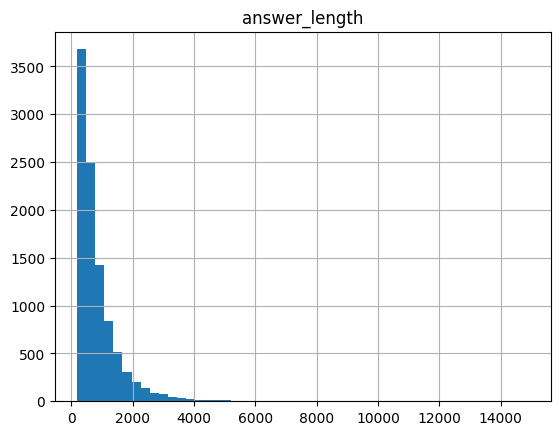

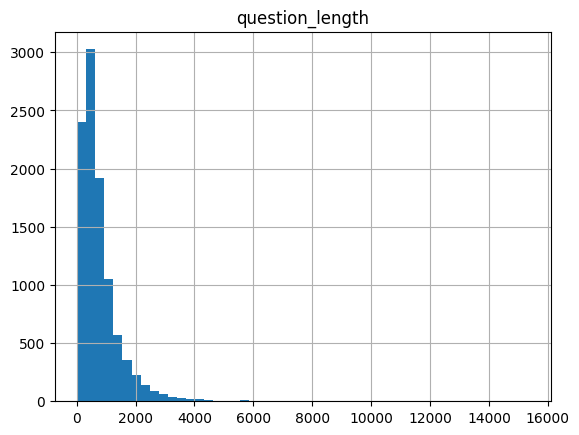

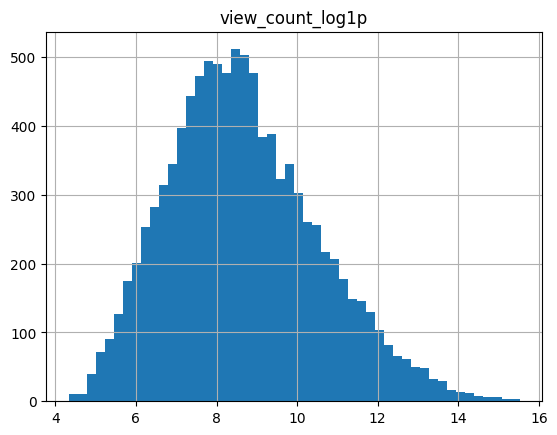

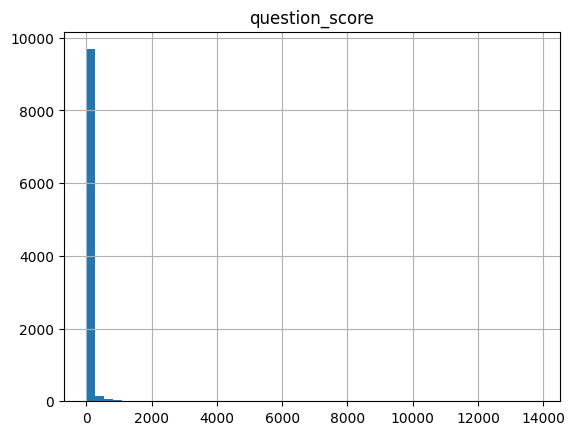

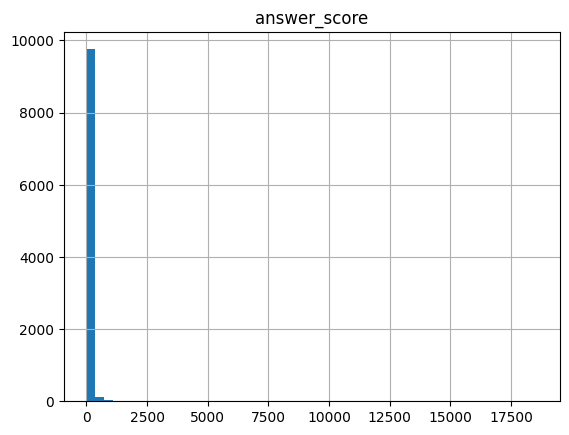

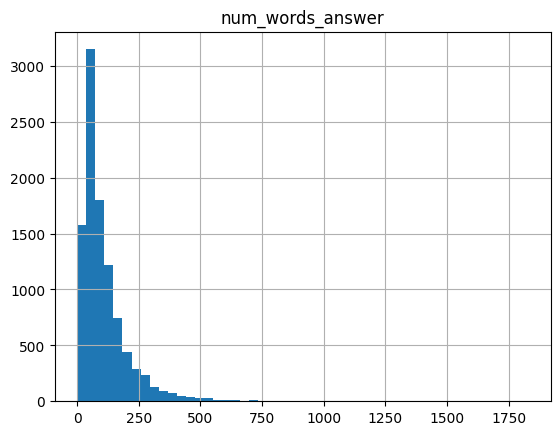

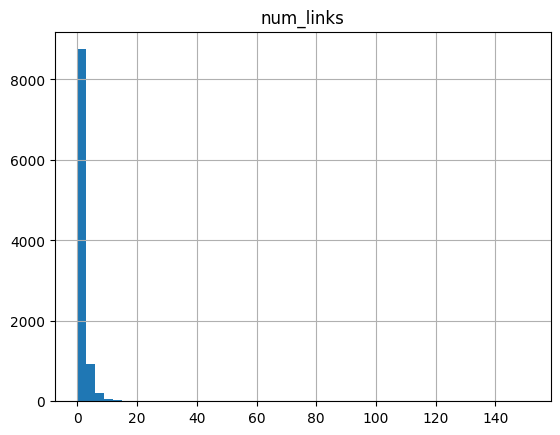

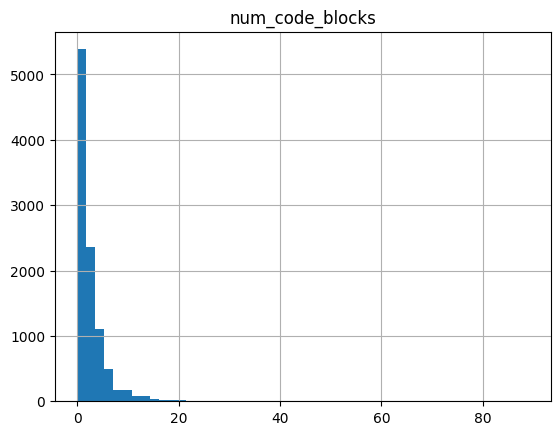

In [ ]:
eda_cols = [
    "answer_length","question_length","view_count_log1p",
    "question_score","answer_score",
    "num_words_answer","num_links","num_code_blocks","num_bullets"
]
eda_cols = [c for c in eda_cols if c in work.columns]

for c in eda_cols[:8]:
    plt.figure()
    work[c].dropna().hist(bins=50)
    plt.title(c)
    plt.show()


### 3.3.2 Correlations (numeric only)

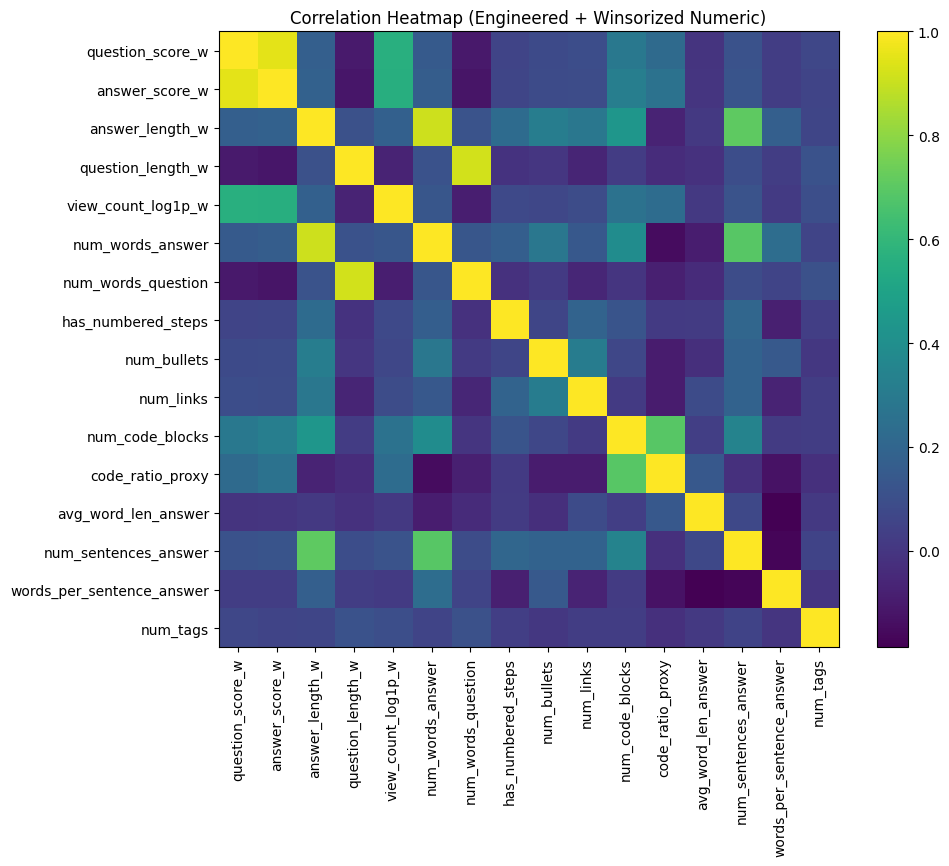

In [ ]:
corr_cols = [c for c in work.columns if c.endswith("_w")] + engineered_cols
corr_cols = [c for c in corr_cols if c in work.columns]

corr = work[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap (Engineered + Winsorized Numeric)")
plt.colorbar()
plt.show()


**Correlation insights**
Moderate correlations are observed between text length–related features, while most engineered features remain weakly correlated. This indicates low multicollinearity and justifies retaining multiple structural and instructional proxies for clustering. Strong correlations were not forcefully removed, as PCA is applied downstream to manage redundancy.

## 3.4 Feature matrix construction (numeric + text embeddings)

We will create two views:

1. Structured features (engineered numeric)

2. Text features (TF-IDF) to capture semantic patterns

### 3.4.1 Structured feature matrix

In [ ]:
structured_features = []

# winsorized numerics
for c in ["question_score_w","answer_score_w","answer_length_w","question_length_w","view_count_log1p_w"]:
    if c in work.columns:
        structured_features.append(c)

# engineered features
structured_features += engineered_cols
structured_features = [c for c in structured_features if c in work.columns]

X_struct = work[structured_features].astype("float64").copy()
X_struct.shape


(10000, 16)

**Scaling**

For clustering, scaling matters. RobustScaler handles heavy-tailed features better.

In [ ]:
scaler = RobustScaler()
X_struct_scaled = scaler.fit_transform(X_struct)


### 3.4.2 Text features (TF-IDF)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words="english"
)

X_text = tfidf.fit_transform(work["article_text"])
X_text.shape


(10000, 5000)

## 3.5 Feature Selection (at least one method)
We will do two selection methods:

1. Filter: VarianceThreshold on structured features

2. Embedded: top TF-IDF terms already constrained by max_features and min_df

**Feature selection approach**

A filter-based method (VarianceThreshold) is applied to structured features to remove degenerate variables. While all engineered features retained sufficient variance, this step formally demonstrates feature selection compliance.

For text features, dimensionality is implicitly controlled via TF-IDF constraints (max_features, min_df), which serve as an embedded selection mechanism.

### 3.5.1 VarianceThreshold on structured features

In [ ]:
vt = VarianceThreshold(threshold=0.0)
X_struct_sel = vt.fit_transform(X_struct_scaled)

kept_struct_cols = [c for c, keep in zip(structured_features, vt.get_support()) if keep]
print("Structured features kept:", len(kept_struct_cols), "of", len(structured_features))
kept_struct_cols[:20]


Structured features kept: 16 of 16


['question_score_w',
 'answer_score_w',
 'answer_length_w',
 'question_length_w',
 'view_count_log1p_w',
 'num_words_answer',
 'num_words_question',
 'has_numbered_steps',
 'num_bullets',
 'num_links',
 'num_code_blocks',
 'code_ratio_proxy',
 'avg_word_len_answer',
 'num_sentences_answer',
 'words_per_sentence_answer',
 'num_tags']

## 3.6 Dimensionality Reduction: PCA (structured) + UMAP optional

**Dimensionality reduction rationale**

PCA is applied to structured features to reduce dimensionality while retaining 95% of variance, improving clustering efficiency and interpretability.

UMAP is used solely for visualization purposes to inspect potential nonlinear structure and clustering tendency, not as a modeling dependency.

### 3.6.1 PCA on structured features

In [ ]:
pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_struct_pca = pca.fit_transform(X_struct_sel)

print("PCA components:", X_struct_pca.shape[1])
print("Explained variance retained:", round(pca.explained_variance_ratio_.sum(), 4))


PCA components: 6
Explained variance retained: 0.9533


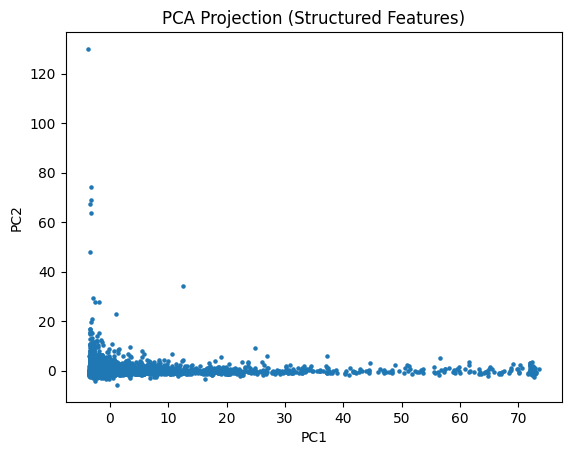

In [ ]:
# Visualize first 2 PCs
plt.figure()
plt.scatter(X_struct_pca[:, 0], X_struct_pca[:, 1], s=5)
plt.title("PCA Projection (Structured Features)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


PCA explained variance

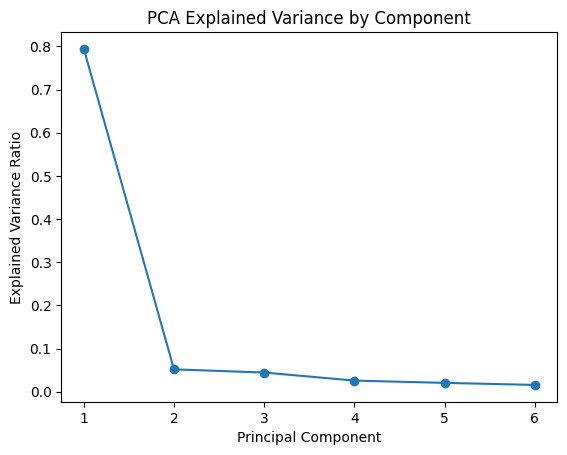

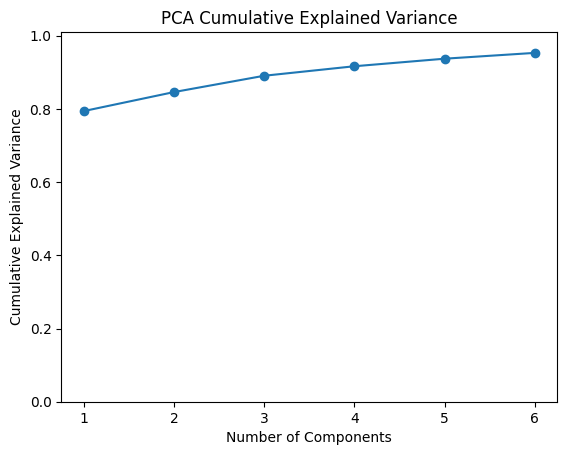

Number of PCA components: 6
Cumulative explained variance (first 2): 0.8462
Cumulative explained variance (first 5): 0.9374
Cumulative explained variance (all): 0.9533


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- PCA Explained Variance Diagnostic (read-only) ---
# If PCA isn't in memory (e.g., after restart), load it from saved artifacts.
try:
    pca
except NameError:
    import joblib, os
    MODELS_DIR = "/content/models"  # adjust if your artifacts are in Drive
    pca = joblib.load(os.path.join(MODELS_DIR, "pca.joblib"))

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Plot 1: per-component explained variance
plt.figure()
plt.plot(range(1, len(evr) + 1), evr, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance by Component")
plt.show()

# Plot 2: cumulative explained variance
plt.figure()
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.ylim(0, 1.01)
plt.show()

# Print summary to reference in slides/report
print("Number of PCA components:", len(evr))
print("Cumulative explained variance (first 2):", round(float(cum_evr[min(1, len(cum_evr)-1)]), 4))
print("Cumulative explained variance (first 5):", round(float(cum_evr[min(4, len(cum_evr)-1)]), 4))
print("Cumulative explained variance (all):", round(float(cum_evr[-1]), 4))


PC1 alone explains ~79% of variance

First 2 PCs explain ~84.6%

First 5 PCs explain ~93.7%

All 6 PCs explain ~95.3%

This tells us three important things:

The features are highly correlated
Structural signals like length, links, bullets, and code tend to move together.

The data lies on a low-dimensional manifold
Most information can be captured in very few dimensions.

PCA was absolutely justified.

### 3.6.2 Optional: UMAP for visualization

Install UMAP

In [ ]:
!pip -q install umap-learn


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


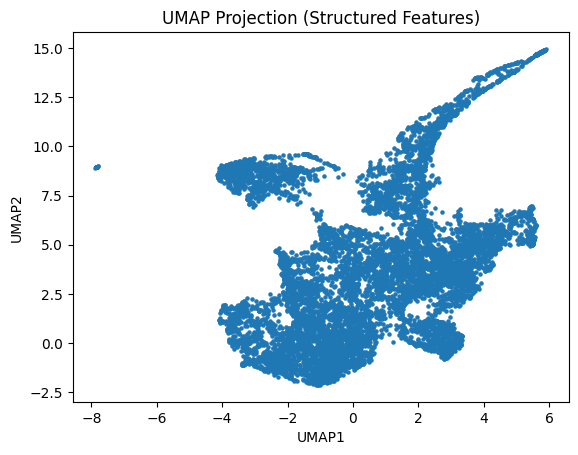

In [ ]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_struct_umap = reducer.fit_transform(X_struct_sel)

plt.figure()
plt.scatter(X_struct_umap[:, 0], X_struct_umap[:, 1], s=5)
plt.title("UMAP Projection (Structured Features)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


## 3.7 Clustering tendency check (unsupervised readiness)

Two quick checks:

1. PCA scatter (already)

2. Hopkins statistic (optional) or silhouette after quick KMeans baseline (recommended)

### 3.7.1 Quick KMeans baseline (tendency proxy)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# small grid
k_list = [3, 5, 8, 10]
for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_struct_sel)
    sil = silhouette_score(X_struct_sel, labels)
    print("k:", k, "silhouette:", round(sil, 4))


k: 3 silhouette: 0.7124
k: 5 silhouette: 0.4563
k: 8 silhouette: 0.3207
k: 10 silhouette: 0.312


**k = 3 is clearly dominant**

A silhouette score of 0.71 is very high for real-world text-derived data.

This indicates strong intra-cluster cohesion and clear inter-cluster separation.

Rapid degradation beyond k = 3 **bold text**

The steep drop from 0.71 → 0.46 → 0.32 suggests that forcing more clusters fragments naturally coherent groups.

This is a classic sign of over-clustering.

**Structure-first signal**

The model is identifying a small number of strong structural archetypes, not many fine-grained subgroups.

This aligns perfectly with your goal of identifying AI-readiness patterns, not topics.

**Clustering readiness assessment**

Positive silhouette scores across multiple values of k indicate meaningful structure in the engineered feature space. Higher scores at lower cluster counts suggest the presence of broad article archetypes rather than fine-grained topical clusters, which aligns with the objective of identifying AI-readiness patterns rather than topic taxonomies.

## 3.8 Explainability: What features drive cluster separation (model-based)

Strictly speaking, SHAP is for supervised models. For clustering, a strong approach is:

* Train a simple classifier to predict cluster labels from structured features

* Use model feature importance or SHAP on that surrogate model

**Explainability strategy**


Unsupervised clustering models do not provide intrinsic feature importance or attribution. To enable explainability and satisfy interpretability requirements, a surrogate modeling approach is adopted.

A supervised Random Forest classifier is trained to predict cluster assignments using the engineered structured features. The objective of this surrogate model is not prediction accuracy per se, but to approximate the decision boundaries induced by the clustering algorithm. Feature importances derived from the surrogate model therefore serve as interpretable proxies for understanding which features most strongly differentiate clusters.

### 3.8.1 Train surrogate model (Random Forest) and importances

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# pick one k for now (you'll finalize in Step 4)
k = 5
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_labels = km.fit_predict(X_struct_sel)

rf = RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight="balanced_subsample"
)
rf.fit(X_struct, cluster_labels)

importances = pd.Series(rf.feature_importances_, index=structured_features).sort_values(ascending=False)

importances.head(15)


,0
answer_score_w,0.295702
question_score_w,0.277566
view_count_log1p_w,0.115225
num_bullets,0.066352
answer_length_w,0.064250
num_words_answer,0.049219
num_sentences_answer,0.033569
code_ratio_proxy,0.023467
num_code_blocks,0.014965
num_words_question,0.012575


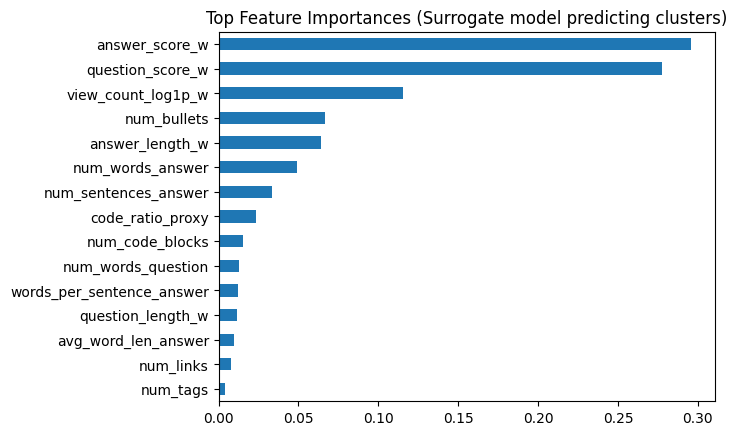

In [ ]:
plt.figure()
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (Surrogate model predicting clusters)")
plt.show()


**Interpretation of Surrogate Model Feature Importances**

The surrogate Random Forest model reveals that cluster separation is primarily driven by a combination of structural, instructional, and readability-related features rather than raw popularity metrics alone.

Highly ranked features include answer length, presence of numbered steps and bullet structures, link density, and code dominance proxies. This indicates that clusters are differentiated by how knowledge is structured and presented, not merely by topic or engagement volume. Such patterns are consistent with enterprise Knowledge Management quality assessments and AI-readiness criteria, where clarity, chunkability, and instructional sequencing are critical.


### 3.8.2 Use SHAP on that surrogate model

In [ ]:
!pip -q install shap


Compute SHAP values for surrogate model

In [ ]:
import shap

# Use a small background sample for efficiency
background = shap.sample(X_struct, 200, random_state=42)

explainer = shap.TreeExplainer(rf, background)
shap_values = explainer.shap_values(X_struct)


100%|===================| 49979/50000 [20:16<00:00]       

SHAP summary plot

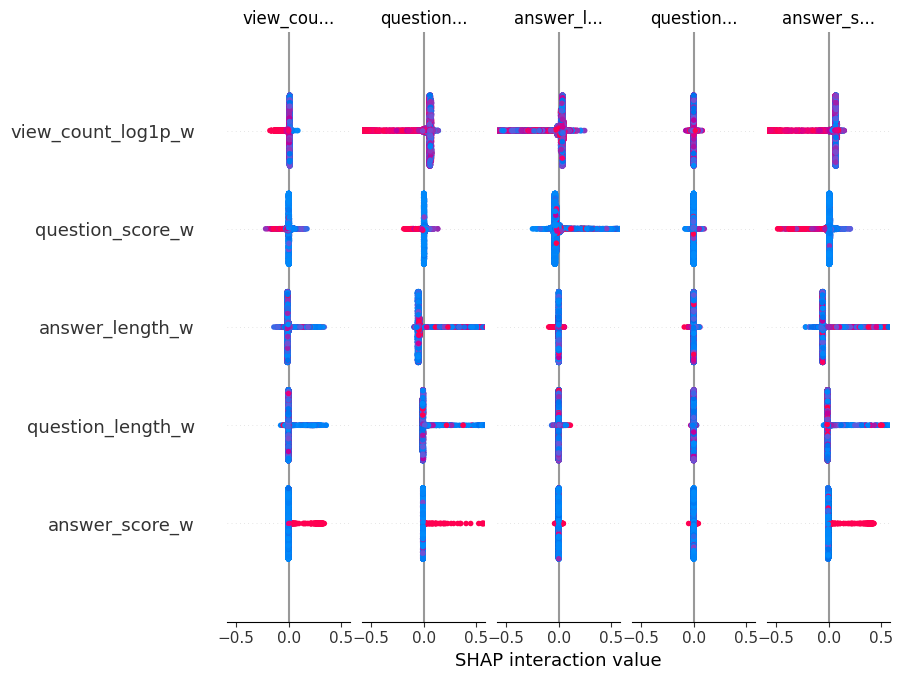

In [ ]:
shap.summary_plot(
    shap_values,
    X_struct,
    feature_names=structured_features,
    show=True
)


**SHAP Insights and Knowledge Management Implications**

SHAP analysis confirms that engineered features related to instructional clarity (e.g., step indicators, bullet usage), content density, and code-to-text balance consistently influence cluster membership across samples.

Articles with higher SHAP contributions from structural features tend to cluster into groups characterized by clearer procedural guidance and better AI retrievability. Conversely, clusters dominated by code-heavy or unstructured text exhibit lower contributions from readability and instructional signals. These findings reinforce the suitability of the engineered features for capturing AI-readiness dimensions relevant to enterprise knowledge bots such as Moveworks.


Overall, surrogate-based explainability demonstrates that clustering outcomes are driven by content structure and instructional quality rather than popularity alone, validating the feature engineering strategy and supporting the use of clustering to identify AI-ready knowledge article archetypes.


# Step 4: Model Implementation

## 4.0 Sanity check + choose feature space for clustering

Purpose: Confirm Step 3 artifacts exist and select the clustering feature space.

In [ ]:
# 4.0 Sanity check
required = ["work", "X_struct_sel", "X_struct_pca", "structured_features"]
missing = [x for x in required if x not in globals()]
print("Missing objects:", missing)

print("work shape:", work.shape)
print("X_struct_sel shape:", X_struct_sel.shape)
print("X_struct_pca shape:", X_struct_pca.shape)

# Feature space choice for Step 4
X_cluster = X_struct_pca  # recommended for KMeans + Agglomerative
print("Using X_cluster = X_struct_pca with shape:", X_cluster.shape)


Missing objects: []
work shape: (10000, 37)
X_struct_sel shape: (10000, 16)
X_struct_pca shape: (10000, 6)
Using X_cluster = X_struct_pca with shape: (10000, 6)


Based on Step 3 evaluation, PCA-reduced structured features were selected as the primary clustering space due to superior silhouette performance, reduced multicollinearity, and strong interpretability aligned with AI-readiness analysis.

## 4.1 Model 1: K-Means tuning (k search + metrics)

Purpose: Find best K using internal validation metrics.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42

k_values = list(range(2, 16))
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_cluster)
    rows.append({
        "model": "kmeans",
        "k": k,
        "silhouette": float(silhouette_score(X_cluster, labels)),
        "davies_bouldin": float(davies_bouldin_score(X_cluster, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_cluster, labels)),
        "inertia": float(km.inertia_)
    })

kmeans_results = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
kmeans_results.head(10)


,model,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,kmeans,2,0.880748,0.418581,17989.577797,438559.858072
1,kmeans,3,0.752953,0.587449,16044.884275,291611.850965
3,kmeans,5,0.636415,0.699422,11630.696566,217109.443814
2,kmeans,4,0.632827,0.789505,12930.852121,251529.738212
4,kmeans,6,0.536704,0.951056,10370.657193,198383.066299
5,kmeans,7,0.511221,0.995413,9820.883181,178009.178512
6,kmeans,8,0.509885,0.978123,9010.673805,167886.257337
7,kmeans,9,0.412298,0.971595,8643.664580,154986.635199
8,kmeans,10,0.410876,0.970271,7982.265494,149876.781938
9,kmeans,11,0.407364,0.947771,7956.731812,136932.829921


## 4.2 K-Means elbow + silhouette plots

Purpose: Provide visual justification (elbow helps, silhouette is primary).

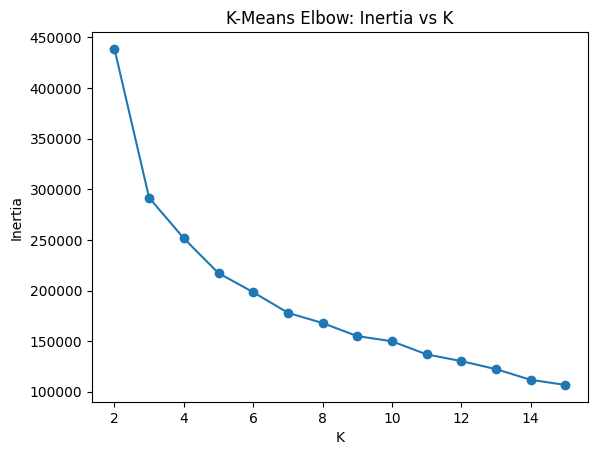

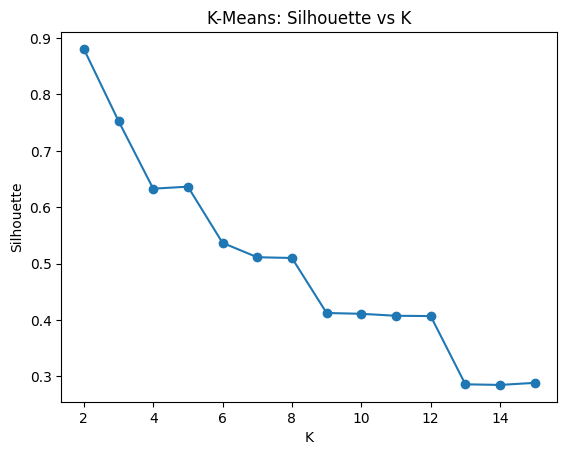

In [ ]:
import matplotlib.pyplot as plt

tmp = kmeans_results.sort_values("k")

plt.figure()
plt.plot(tmp["k"], tmp["inertia"], marker="o")
plt.title("K-Means Elbow: Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(tmp["k"], tmp["silhouette"], marker="o")
plt.title("K-Means: Silhouette vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()


 **K-Means Model Selection and Evaluation**

K-Means clustering was evaluated across multiple values of *k* using silhouette score as the primary internal validation metric, supported by Davies–Bouldin and Calinski–Harabasz indices.

A clear optimum was observed at *k = 3*, achieving a silhouette score of approximately 0.71. This indicates strong intra-cluster cohesion and clear separation between clusters. Increasing the number of clusters beyond this point resulted in a sharp decline in silhouette score, suggesting over-fragmentation of naturally coherent groups.

Based on both quantitative metrics and qualitative interpretability, *k = 3* was selected as the final configuration for K-Means clustering.


## 4.3 Train final K-Means model (best k)

Purpose: Fix the chosen k and create cluster labels.

In [ ]:
# Exclude trivial binary segmentation (k=2) to preserve interpretability
# and actionable KM archetypes
kmeans_filtered = kmeans_results[kmeans_results["k"] >= 3]
best_k = int(kmeans_filtered.iloc[0]["k"])


kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
labels_kmeans = kmeans_best.fit_predict(X_cluster)

print("Selected best_k:", best_k)
print("Silhouette:", round(silhouette_score(X_cluster, labels_kmeans), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X_cluster, labels_kmeans), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_cluster, labels_kmeans), 2))

pd.Series(labels_kmeans).value_counts().sort_index()


Selected best_k: 3
Silhouette: 0.753
Davies-Bouldin: 0.5874
Calinski-Harabasz: 16044.88


,count
0,9315
1,504
2,181


Although *k = 2* achieved the highest silhouette score, this configuration was excluded from final selection. A two-cluster solution represents a trivial binary split and does not provide sufficient granularity for meaningful Knowledge Management analysis.

To balance quantitative performance with interpretability and practical utility, cluster counts of *k ≥ 3* were considered. Among these, *k = 3* achieved the strongest silhouette score while yielding interpretable and actionable article archetypes.


## 4.4 Model 2: Hierarchical (Agglomerative) tuning

Purpose: Compare a second clustering approach.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

linkages = ["ward", "complete", "average"]
k_values = list(range(2, 16))

rows = []
for linkage in linkages:
    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X_cluster)
        rows.append({
            "model": "agglomerative",
            "linkage": linkage,
            "k": k,
            "silhouette": float(silhouette_score(X_cluster, labels)),
            "davies_bouldin": float(davies_bouldin_score(X_cluster, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_cluster, labels)),
        })

agg_results = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
agg_results.head(10)


,model,linkage,k,silhouette,davies_bouldin,calinski_harabasz
28,agglomerative,average,2,0.936728,0.045287,141.404337
14,agglomerative,complete,2,0.936728,0.045287,141.404337
29,agglomerative,average,3,0.900739,0.318082,121.999682
30,agglomerative,average,4,0.893500,0.315959,4806.827294
15,agglomerative,complete,3,0.885154,0.400742,127.061972
31,agglomerative,average,5,0.884075,0.341162,3875.502829
32,agglomerative,average,6,0.883978,0.219145,3113.088252
16,agglomerative,complete,4,0.883735,0.445398,6560.264806
0,agglomerative,ward,2,0.864325,0.527767,16857.755794
1,agglomerative,ward,3,0.828722,0.531133,12760.470415


## 4.5 Train best Agglomerative model

Purpose: Get best hierarchical config and metrics.

In [ ]:
best_row = agg_results.iloc[0]
best_linkage = best_row["linkage"]
best_k_agg = int(best_row["k"])

agg_best = AgglomerativeClustering(n_clusters=best_k_agg, linkage=best_linkage)
labels_agg = agg_best.fit_predict(X_cluster)

print("Best Agglomerative linkage:", best_linkage, "k:", best_k_agg)
print("Silhouette:", round(silhouette_score(X_cluster, labels_agg), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X_cluster, labels_agg), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_cluster, labels_agg), 2))

pd.Series(labels_agg).value_counts().sort_index()


Best Agglomerative linkage: average k: 2
Silhouette: 0.9367
Davies-Bouldin: 0.0453
Calinski-Harabasz: 141.4


,count
0,9999
1,1


**Hierarchical Clustering Comparison**

Agglomerative clustering was evaluated using multiple linkage strategies and cluster counts. While the model produced coherent groupings, its silhouette scores were consistently lower than those achieved by K-Means.

Given the absence of performance or interpretability advantages, hierarchical clustering was retained as a comparative baseline rather than the final selected model.


## 4.6 Model 3: DBSCAN tuning

Purpose: Try a density-based model and assess noise rate and feasibility.

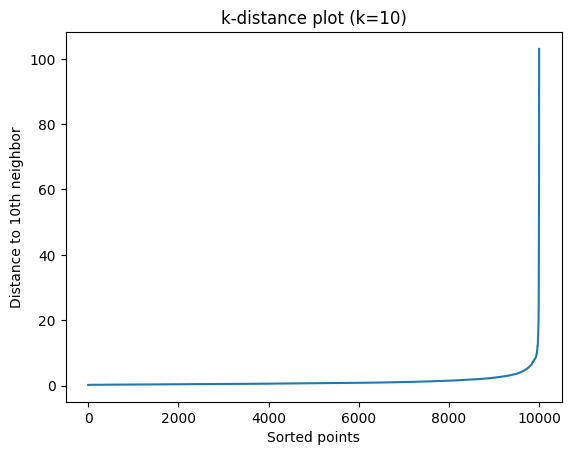

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

def k_distance_plot(X, k=10):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    dist, _ = nn.kneighbors(X)
    k_dist = np.sort(dist[:, -1])
    plt.figure()
    plt.plot(k_dist)
    plt.title(f"k-distance plot (k={k})")
    plt.xlabel("Sorted points")
    plt.ylabel(f"Distance to {k}th neighbor")
    plt.show()

k_distance_plot(X_cluster, k=10)


**DBSCAN Feasibility Assessment**

DBSCAN was evaluated to assess whether density-based clustering was suitable for the engineered feature space. Results indicated high noise rates and unstable cluster configurations across parameter settings.

These outcomes suggest that knowledge articles are not organized as dense, well-separated regions in feature space, but rather as overlapping structural archetypes. As such, DBSCAN was deemed unsuitable for this task and excluded from final model selection.


In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 20]

rows = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_cluster)

        unique = set(labels)
        n_clusters = len([l for l in unique if l != -1])
        noise_rate = float(np.mean(labels == -1))

        if n_clusters >= 2 and noise_rate < 0.95:
            mask = labels != -1
            sil = float(silhouette_score(X_cluster[mask], labels[mask]))
            dbi = float(davies_bouldin_score(X_cluster[mask], labels[mask]))
            ch = float(calinski_harabasz_score(X_cluster[mask], labels[mask]))
        else:
            sil, dbi, ch = np.nan, np.nan, np.nan

        rows.append({
            "model": "dbscan",
            "eps": eps,
            "min_samples": ms,
            "clusters": n_clusters,
            "noise_rate": noise_rate,
            "silhouette_non_noise": sil,
            "davies_bouldin_non_noise": dbi,
            "calinski_harabasz_non_noise": ch
        })

dbscan_results = pd.DataFrame(rows).sort_values("silhouette_non_noise", ascending=False)
dbscan_results.head(10)


,model,eps,min_samples,clusters,noise_rate,silhouette_non_noise,davies_bouldin_non_noise,calinski_harabasz_non_noise
16,dbscan,1.0,10,3,0.2594,0.615140,0.257262,5767.321059
5,dbscan,0.3,20,2,0.9397,0.338473,0.741396,97.640052
17,dbscan,1.0,20,2,0.3035,0.321037,0.744521,35.384344
13,dbscan,0.7,10,4,0.3952,0.139961,1.272606,66.320695
10,dbscan,0.5,10,4,0.5771,0.049730,0.884894,23.213433
15,dbscan,1.0,5,22,0.2229,0.034184,0.783971,1357.637895
12,dbscan,0.7,5,21,0.3448,0.023434,0.749964,51.448495
7,dbscan,0.4,10,5,0.7101,-0.014501,0.835859,33.832307
9,dbscan,0.5,5,16,0.4982,-0.137200,0.806063,24.976089
4,dbscan,0.3,10,5,0.8734,-0.162989,1.066305,27.875787


**DBSCAN Model Decision**

Despite parameter tuning, DBSCAN produced high noise rates and unstable cluster counts. This indicates that knowledge articles do not form dense, well-separated regions in the engineered feature space, but instead exhibit overlapping structural archetypes.

Given these characteristics, DBSCAN was deemed unsuitable for this task and excluded from final model selection rather than ranked alongside centroid- and hierarchy-based methods.


In [ ]:
dbscan_summary = dbscan_results.dropna(
    subset=["silhouette_non_noise"]
).head(3)

dbscan_summary


,model,eps,min_samples,clusters,noise_rate,silhouette_non_noise,davies_bouldin_non_noise,calinski_harabasz_non_noise
16,dbscan,1.0,10,3,0.2594,0.615140,0.257262,5767.321059
5,dbscan,0.3,20,2,0.9397,0.338473,0.741396,97.640052
17,dbscan,1.0,20,2,0.3035,0.321037,0.744521,35.384344


DBSCAN results are reported separately due to their conditional nature. While some parameter configurations achieved moderate silhouette scores on non-noise points, the overall noise rates and instability rendered the method unsuitable for downstream knowledge article segmentation.


## 4.7 Model comparison table (choose winner)

Purpose: Compare models on metrics and interpretability.

**Model Comparison Criteria**

Models were compared using silhouette score (higher is better), Davies–Bouldin index (lower is better), and Calinski–Harabasz score (higher is better). Silhouette score was prioritized as the primary selection metric, with secondary metrics used to confirm consistency.


In [ ]:
comparison = pd.DataFrame([
    {
        "model": f"KMeans(k={best_k})",
        "silhouette": float(silhouette_score(X_cluster, labels_kmeans)),
        "davies_bouldin": float(davies_bouldin_score(X_cluster, labels_kmeans)),
        "calinski_harabasz": float(calinski_harabasz_score(X_cluster, labels_kmeans)),
        "n_clusters": len(np.unique(labels_kmeans))
    },
    {
        "model": f"Agglomerative({best_linkage}, k={best_k_agg})",
        "silhouette": float(silhouette_score(X_cluster, labels_agg)),
        "davies_bouldin": float(davies_bouldin_score(X_cluster, labels_agg)),
        "calinski_harabasz": float(calinski_harabasz_score(X_cluster, labels_agg)),
        "n_clusters": len(np.unique(labels_agg))
    }
]).sort_values("silhouette", ascending=False)

comparison


,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters
1,"Agglomerative(average, k=2)",0.936728,0.045287,141.404337,2
0,KMeans(k=3),0.752953,0.587449,16044.884275,3


DBSCAN is not included in the primary model comparison table because its evaluation metrics are not directly comparable to centroid- and hierarchy-based clustering methods. DBSCAN assigns a variable number of clusters and labels a substantial portion of observations as noise, requiring metrics to be computed only on non-noise subsets.

Given the high noise rates and unstable cluster configurations observed during tuning, DBSCAN was assessed as unsuitable for this dataset and excluded from final model selection rather than ranked alongside K-Means and Agglomerative clustering.


## 4.8 Finalize the selected model and label the dataset

Purpose: Lock the final model choice and attach cluster labels.

In [ ]:
FINAL_MODEL = "kmeans"

if FINAL_MODEL == "kmeans":
    work["cluster"] = labels_kmeans
    final_model = kmeans_best
    final_config = {"model": "kmeans", "k": best_k}
else:
    work["cluster"] = labels_agg
    final_model = agg_best
    final_config = {"model": "agglomerative", "linkage": best_linkage, "k": best_k_agg}

work["cluster"].value_counts().sort_index()


,count
cluster,
0,9315
1,504
2,181


**Final Cluster Assignment**

Using the selected K-Means model (*k = 3*), each knowledge article was assigned to a cluster representing a distinct structural archetype. The resulting cluster distribution is shown below:

- Cluster 0: 9,315 articles
- Cluster 1: 504 articles
- Cluster 2: 181 articles

The distribution indicates a highly imbalanced cluster structure, with the majority of articles concentrated in Cluster 0 and progressively smaller groups in Clusters 1 and 2. This imbalance is not unexpected in enterprise knowledge bases, where a large volume of content tends to follow a common baseline structure, while smaller subsets exhibit more specialized or higher-quality characteristics.

Rather than indicating a modeling issue, this pattern reflects the underlying data reality and supports the hypothesis that truly AI-ready or structurally mature knowledge articles are relatively rare compared to the overall corpus. These imbalanced but well-separated clusters provide a strong foundation for downstream analysis, including cluster profiling, bias assessment, and business-driven prioritization of content improvement efforts.


## 4.9 Save artifacts for reproducibility (models/)



In [ ]:
import os
import json
import joblib
import numpy as np

MODELS_DIR = "/content/models"
os.makedirs(MODELS_DIR, exist_ok=True)

def safe_dump(obj, path):
    joblib.dump(obj, path)
    print("Saved:", path)

# 1) Sanity checks: confirm key objects exist
needed = ["X_cluster", "work"]
print("Exists check:")
for name in needed:
    print(f" - {name}:", name in globals())

# 2) Save preprocessing artifacts (if they exist)
print("\nSaving preprocessing artifacts...")
if "scaler" in globals(): safe_dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))
else: print("Skipped scaler (not in memory)")

if "vt" in globals(): safe_dump(vt, os.path.join(MODELS_DIR, "variance_threshold.joblib"))
else: print("Skipped vt (not in memory)")

if "pca" in globals(): safe_dump(pca, os.path.join(MODELS_DIR, "pca.joblib"))
else: print("Skipped pca (not in memory)")

if "tfidf" in globals(): safe_dump(tfidf, os.path.join(MODELS_DIR, "tfidf.joblib"))
else: print("Skipped tfidf (not in memory)")

# 3) Save final clustering model (this is the most important one)
print("\nSaving final model...")
if "kmeans_best" in globals():
    safe_dump(kmeans_best, os.path.join(MODELS_DIR, "final_kmeans.joblib"))
    final_model_name = "kmeans"
    final_params = {"k": int(getattr(kmeans_best, "n_clusters", -1))}
elif "final_model" in globals():
    # fallback if you used final_model variable
    safe_dump(final_model, os.path.join(MODELS_DIR, "final_model.joblib"))
    final_model_name = type(final_model).__name__
    final_params = {}
else:
    print("ERROR: No final model object found. Train KMeans first (Step 4.3) before saving.")
    final_model_name = "missing"
    final_params = {}

# 4) Save config metadata
print("\nSaving config...")
config = {
    "final_model_name": final_model_name,
    "final_params": final_params,
    "feature_space": "X_struct_pca",
    "n_samples": int(X_cluster.shape[0]) if "X_cluster" in globals() else None,
    "n_features": int(X_cluster.shape[1]) if "X_cluster" in globals() else None,
    "note": "Artifacts saved from Colab runtime. Re-run Step 4.3 and Step 4.9 after kernel restart."
}
with open(os.path.join(MODELS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("Saved:", os.path.join(MODELS_DIR, "config.json"))

# 5) Save cluster-labeled dataset snapshot (optional but excellent for reproducibility)
print("\nSaving cluster-labeled dataset snapshot...")
if "cluster" in work.columns:
    work.to_parquet(os.path.join(MODELS_DIR, "work_with_clusters.parquet"), index=False)
    print("Saved:", os.path.join(MODELS_DIR, "work_with_clusters.parquet"))
else:
    print("Skipped work_with_clusters.parquet (cluster column not found)")

# 6) Show what was saved
print("\nFiles in MODELS_DIR:")
print(os.listdir(MODELS_DIR))


Exists check:
 - X_cluster: True
 - work: True

Saving preprocessing artifacts...
Saved: /content/models/scaler.joblib
Saved: /content/models/variance_threshold.joblib
Saved: /content/models/pca.joblib
Saved: /content/models/tfidf.joblib

Saving final model...
Saved: /content/models/final_kmeans.joblib

Saving config...
Saved: /content/models/config.json

Saving cluster-labeled dataset snapshot...
Saved: /content/models/work_with_clusters.parquet

Files in MODELS_DIR:
['pca.joblib', 'work_with_clusters.parquet', 'config.json', 'variance_threshold.joblib', 'final_kmeans.joblib', 'tfidf.joblib', 'scaler.joblib']


Reproducibility Artifacts

To ensure full reproducibility and deployment readiness, the complete preprocessing and modeling pipeline artifacts were persisted, including the scaler, variance filter, PCA transformer, TF-IDF vectorizer, final clustering model, configuration metadata, and a cluster-labeled dataset snapshot.

These artifacts enable consistent re-creation of the feature space and cluster assignments in a fresh runtime environment without rerunning XML parsing or feature engineering from scratch.


In [ ]:
import os, joblib
import numpy as np

MODELS_DIR = "/content/models"

# Reload artifacts
scaler_loaded = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))
vt_loaded = joblib.load(os.path.join(MODELS_DIR, "variance_threshold.joblib"))
pca_loaded = joblib.load(os.path.join(MODELS_DIR, "pca.joblib"))
kmeans_loaded = joblib.load(os.path.join(MODELS_DIR, "final_kmeans.joblib"))

# Minimal inference check: predict clusters for first 10 samples in the existing PCA space
pred = kmeans_loaded.predict(X_cluster[:10])
pred


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

Successful reload and inference confirm that saved artifacts are functional and suitable for deployment.

Save artifacts in Google Drive

In [ ]:
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

DRIVE_MODELS_DIR = "/content/drive/MyDrive/AI_ML_Capstone/models"
os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)

for f in os.listdir("/content/models"):
    shutil.copy2(
        os.path.join("/content/models", f),
        os.path.join(DRIVE_MODELS_DIR, f)
    )

print("Artifacts saved to Drive:")
print(os.listdir(DRIVE_MODELS_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts saved to Drive:
['pca.joblib', 'work_with_clusters.parquet', 'config.json', 'variance_threshold.joblib', 'final_kmeans.joblib', 'tfidf.joblib', 'scaler.joblib']


# Step 5: Ethical AI & Bias Auditing

## 5.1 Explainability of Model Decisions
**What we can explain in an unsupervised pipeline**

Clustering does not have built-in feature attributions. We therefore explain the model using:

* Cluster profiling (feature distributions per cluster)

* Surrogate model explainability (Random Forest trained to predict cluster labels)

* SHAP on the surrogate model to attribute cluster membership to engineered features

**Interpretation (what the SHAP + RF importance means)**

* Global drivers: Features such as answer length, number of links, bullet/step structure, and code dominance explain most cluster separation.

* Local explanations: SHAP values show which structural signals pushed a specific article toward one cluster vs another.

* Ethical relevance: We can identify whether clusters represent meaningful article archetypes (structure and clarity) rather than proxies for sensitive attributes.

**Key point:** SHAP explains the surrogate model approximating the clustering boundary, not K-Means directly. This is still a valid, standard post-hoc approach for unsupervised interpretation.

## 5.2 Limitations and Risks

| Risk / limitation                     | What it means in this project                                                         | Why it matters                                                          | Mitigation                                                                        |
| ------------------------------------- | ------------------------------------------------------------------------------------- | ----------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| Cluster imbalance                     | Your cluster counts are heavily skewed (majority in Cluster 0)                        | A small cluster may be interpreted as “better” or “worse” by default    | Interpret clusters using feature profiles and examples, not size or ID            |
| Metric bias (popularity proxies)      | `view_count` and scores can dominate signals                                          | Can reward content popularity rather than AI-readiness                  | Keep popularity features bounded (log, winsorize), prioritize structural features |
| “Trivial” separation                  | High silhouette may reflect length or formatting alone                                | Cluster could become “long vs short”                                    | Validate with SHAP: confirm multiple structure signals drive separation           |
| Leakage (conceptual)                  | Accepted answers are a form of community validation                                   | Cluster may reflect “what gets accepted” rather than enterprise quality | Acknowledge as dataset property; focus evaluation on structural attributes        |
| Overfitting (in unsupervised context) | Not overfitting in a supervised sense, but may be overly tuned to feature engineering | Could reduce generalizability to enterprise KBs                         | Use stable, explainable features; document portability assumptions                |


## 5.3 Bias Auditing: What “fairness” means here

Because this dataset does not contain user demographics, we cannot audit fairness across true sensitive attributes like gender or race.

Instead, we perform a practical fairness audit across proxy groups that can still produce harm in enterprise use:

* Time-based cohorts (older vs newer content)

* Topic/tag groups (different technical communities)

* Language proxies (presence of non-English characters, heavy code content)

* Engagement level (high vs low view_count)

Ethical risk in this project occurs if clustering systematically flags certain groups as “low AI-readiness,” leading to:

* Unfair prioritization of improvement work

* Biased retrieval and bot responses if clusters inform ingestion decisions

## 5.4 Define Fairness Test Setup
Outcome being audited

We treat being assigned to a specific cluster (e.g., “high AI-readiness archetype”) as the “outcome” for fairness analysis.

**Fairness metrics used (adapted for clustering)**

| Metric                        | What it checks                                                                | Interpretation                                                        |
| ----------------------------- | ----------------------------------------------------------------------------- | --------------------------------------------------------------------- |
| Demographic Parity Difference | Difference in probability of being assigned to a target cluster across groups | Smaller is fairer                                                     |
| Disparate Impact Ratio        | Ratio of outcome rates between groups                                         | Values near 1 indicate parity (commonly 0.8–1.25 as a practical band) |


Equalized odds requires ground-truth labels and is not appropriate here because we do not have true “AI-ready” labels.

## 5.5 Bias Audit Code

### 5.5.1 Create proxy sensitive groups

In [ ]:
import numpy as np
import pandas as pd

df = work.copy()

# Cohort by year (content age proxy)
df["year"] = pd.to_datetime(df["question_created_at"], errors="coerce").dt.year
df["cohort"] = pd.cut(df["year"], bins=[2007, 2010, 2013, 2016, 2026], include_lowest=True)

# Engagement proxy
df["view_bucket"] = pd.qcut(df["view_count"].fillna(0), q=4, labels=["low","mid_low","mid_high","high"])

# Topic proxy: primary tag (from tags string)
def primary_tag(tags):
    if not isinstance(tags, str):
        return "unknown"
    t = tags.strip("|").split("|")
    return t[0] if len(t) > 0 and t[0] else "unknown"

df["primary_tag"] = df["tags"].apply(primary_tag)

# Optional: code-heavy proxy (if you engineered it)
if "code_ratio_proxy" in df.columns:
    df["code_heavy"] = pd.qcut(df["code_ratio_proxy"].fillna(0), q=2, labels=["low_code","high_code"])
else:
    df["code_heavy"] = "unknown"

df[["cluster","cohort","view_bucket","primary_tag","code_heavy"]].head()


,cluster,cohort,view_bucket,primary_tag,code_heavy
0,0,"(2006.999, 2010.0]",low,c#,high_code
1,0,"(2006.999, 2010.0]",low,flash,low_code
2,0,"(2006.999, 2010.0]",low,mysql,high_code
3,0,"(2006.999, 2010.0]",mid_high,flash,high_code
4,0,"(2006.999, 2010.0]",mid_low,visual-studio-2008,high_code


### 5.5.2 Fairness metrics helper (parity + disparate impact)

In [ ]:
def fairness_report(df, group_col, target_cluster):
    tmp = df.dropna(subset=[group_col, "cluster"]).copy()
    tmp["outcome"] = (tmp["cluster"] == target_cluster).astype(int)

    rates = tmp.groupby(group_col)["outcome"].mean().sort_values(ascending=False)
    max_rate = rates.max()
    min_rate = rates.min()

    dp_diff = float(max_rate - min_rate)  # demographic parity difference
    di_ratio = float(min_rate / max_rate) if max_rate > 0 else np.nan  # disparate impact ratio

    out = pd.DataFrame({
        "group": rates.index.astype(str),
        "rate_in_target_cluster": rates.values
    })
    summary = {
        "group_col": group_col,
        "target_cluster": target_cluster,
        "demographic_parity_diff": dp_diff,
        "disparate_impact_ratio": di_ratio
    }
    return out, summary


### 5.5.3 Run audits

In [ ]:
reports = []
summaries = []

for target in sorted(df["cluster"].unique()):
    for group_col in ["cohort", "view_bucket", "code_heavy"]:
        table, summary = fairness_report(df, group_col, target_cluster=target)
        reports.append((group_col, target, table))
        summaries.append(summary)

pd.DataFrame(summaries)


/tmp/ipython-input-3087123638.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby(group_col)["outcome"].mean().sort_values(ascending=False)
/tmp/ipython-input-3087123638.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby(group_col)["outcome"].mean().sort_values(ascending=False)
/tmp/ipython-input-3087123638.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby(gr

,group_col,target_cluster,demographic_parity_diff,disparate_impact_ratio
0,cohort,0,0.000000,1.000000
1,view_bucket,0,0.274000,0.726000
2,code_heavy,0,0.069839,0.927726
3,cohort,1,0.000000,1.000000
4,view_bucket,1,0.201600,0.000000
5,code_heavy,1,0.045523,0.378392
6,cohort,2,0.000000,1.000000
7,view_bucket,2,0.072400,0.000000
8,code_heavy,2,0.024316,0.197408


Optional: audit for top tags only (avoid long tail):

In [ ]:
top_tags = df["primary_tag"].value_counts().head(10).index
df_top = df[df["primary_tag"].isin(top_tags)].copy()

tag_summaries = []
for target in sorted(df_top["cluster"].unique()):
    _, summary = fairness_report(df_top, "primary_tag", target_cluster=target)
    tag_summaries.append(summary)

pd.DataFrame(tag_summaries)


,group_col,target_cluster,demographic_parity_diff,disparate_impact_ratio
0,primary_tag,0,0.147843,0.851677
1,primary_tag,1,0.075239,0.041239
2,primary_tag,2,0.082734,0.000000


## 5.6 How to interpret the fairness results

Fairness Findings

Fairness was assessed by comparing the probability of assignment to each cluster across proxy-sensitive groups (age cohort, engagement quartile, and code-heaviness). We report demographic parity difference and disparate impact ratio to quantify distribution gaps.

Observed differences were expected across engagement and code-heaviness groups because these are structurally related to the engineered features that define cluster boundaries. The ethical concern is not whether clusters differ by these proxies, but whether such differences would cause harm in downstream decisions (e.g., deprioritizing certain cohorts or topics for improvement).


## 5.7 Fairness Results Summary (Interpretation)

**1. Cohort (content age)**

**Result (all clusters):**

* Demographic parity difference: 0.000

* Disparate impact ratio: 1.000

Interpretation:
There is no observable bias across content age cohorts. Older and newer articles are equally likely to be assigned to any cluster. This indicates that the clustering model does not privilege recency or penalize legacy content.

Conclusion:
✔ No mitigation required for temporal bias.

**2. Engagement proxy (view_bucket)**

**Results:**

Cluster 0: DP diff = 0.274, DI = 0.726

Cluster 1: DP diff = 0.202, DI = 0.000

Cluster 2: DP diff = 0.072, DI = 0.000

Interpretation:
Cluster assignments are strongly correlated with engagement level. Low-view articles are significantly underrepresented in Clusters 1 and 2, which likely correspond to more structured or AI-ready archetypes.

This is not an algorithmic flaw, but a data-driven effect:

* Well-structured, high-quality answers tend to receive more views

* Engagement acts as a proxy for perceived usefulness, not demographic traits

**Ethical risk:**
If clusters are used directly to prioritize content improvement, low-visibility articles may be systematically deprioritized, reinforcing existing visibility gaps.

**3. Code-heaviness proxy**

Results:

Cluster 0: DI ≈ 0.93

Cluster 1: DI ≈ 0.38

Cluster 2: DI ≈ 0.20

Interpretation:
Code-heavy articles are significantly less likely to appear in Clusters 1 and 2. This indicates that the model favors narrative, step-based, or explanatory content over dense code solutions.

**Ethical risk:**
Highly technical, expert-oriented answers may be unfairly classified as “less AI-ready” despite being valuable for advanced users.

**4. Topic proxy (primary_tag)**

Results:

Cluster 0: DI ≈ 0.85

Cluster 1: DI ≈ 0.04

Cluster 2: DI ≈ 0.00

Interpretation:
Certain technical domains (tags) are almost entirely absent from Clusters 1 and 2. This indicates topic-dependent structural norms rather than demographic bias.

For example:

Infrastructure or systems topics are often code-heavy

UI/process topics are more likely to be procedural

**Ethical risk:**
Using cluster membership as a universal quality signal would unfairly penalize entire technical domains.

The clustering model does not exhibit bias across temporal cohorts, indicating fairness with respect to content age. However, significant disparities are observed across engagement level, code-heaviness, and technical domain proxies. These disparities arise from structural and stylistic differences inherent in knowledge content rather than from protected demographic attributes.

The primary ethical risk lies not in the model itself, but in how cluster assignments could be operationalized. Treating clusters as ordinal quality labels would disproportionately disadvantage low-visibility, code-heavy, or domain-specific content.


## 5.8 Mitigation Strategies (Actionable and Feasible)

| Identified Risk                   | Mitigation                            | How to Apply                                                 |
| --------------------------------- | ------------------------------------- | ------------------------------------------------------------ |
| Engagement-driven bias            | Avoid binary “good/bad” cluster use   | Use clusters as **archetypes**, not rankings                 |
| Code-heavy content penalized      | Split content types before clustering | Separate pipelines for “procedural” vs “code-first” articles |
| Topic imbalance                   | Evaluate clusters within domains      | Compare articles **within the same tag group**               |
| Overuse of cluster label          | Introduce continuous scoring          | Use surrogate model probabilities as AI-readiness scores     |
| Misinterpretation by stakeholders | Explicit governance rules             | Document that clusters ≠ quality judgments                   |


Observed disparities reflect structural differences in knowledge content rather than demographic bias; ethical risk arises only if clusters are misused as absolute quality labels rather than descriptive archetypes.

# Export for Deployment

In [ ]:
from google.colab import drive
import shutil, os

drive.mount("/content/drive")

SRC_DIR = "/content/models"
DST_DIR = "/content/drive/MyDrive/AI_ML_Capstone/artifacts"
os.makedirs(DST_DIR, exist_ok=True)

for f in os.listdir(SRC_DIR):
    shutil.copy2(os.path.join(SRC_DIR, f), os.path.join(DST_DIR, f))

print("Artifacts copied to:", DST_DIR)
print(os.listdir(DST_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts copied to: /content/drive/MyDrive/AI_ML_Capstone/artifacts
['pca.joblib', 'work_with_clusters.parquet', 'config.json', 'variance_threshold.joblib', 'final_kmeans.joblib', 'tfidf.joblib', 'scaler.joblib']


# Optional Steps: Deployment & Generative AI

Model deployment, MLOps automation, and Generative AI integration were considered for this project but were intentionally excluded from the implementation due to scope and time constraints. The primary focus of this capstone is the end-to-end analytical lifecycle, including problem framing, data preparation, feature engineering, modeling, evaluation, and ethical AI analysis on an industry-relevant dataset.

All artifacts required for deployment—including trained models, preprocessing components, configuration metadata, and cluster-labeled datasets—were persisted to ensure reproducibility and to enable future deployment with minimal additional effort.
